#“Predictive Maintenance with Multivariate Time Windows: from academic baseline to more rigorous temporal validation”

## Recovery / Resume Notes

There are two valid recovery modes in a new Colab session:

1. Continue training:
- mount Drive
- run the infrastructure cells
- recreate the model
- call `fit(...)` with persistent callbacks

2. Only load and evaluate:
- mount Drive
- run the infrastructure cells
- load `best_model.keras`
- run the evaluation cells

For the multi-step section, prefer using:
- `force_retrain=False, evaluate_only_if_exists=True` to only load
- `force_retrain=False, evaluate_only_if_exists=False` to continue normally
- `force_retrain=True, evaluate_only_if_exists=False` to restart from scratch

## 1. Dependencies

In [1]:
import json
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, concatenate, Conv1D, MaxPooling1D, Flatten, Dropout

from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration and Utilities

In [3]:
def plot_data(temperatures, vibrations, fails, start, stop):

    plt.style.use('dark_background')
    plt.rcParams['figure.figsize'] = (8,6)
    plt.rcParams['lines.linewidth'] = 3
    plt.rcParams['font.size'] = 15

    plt.figure(figsize=(15, 12))

    plt.subplot(3, 1, 1)
    plt.plot(temperatures[start:stop], color="yellow", lw=5)
    plt.title('Temperatura')

    plt.subplot(3, 1, 2)
    plt.plot(vibrations[start:stop], color="blue", lw=5)
    plt.title('Vibração')

    plt.subplot(3, 1, 3)
    plt.plot(fails[start:stop], color="red", marker='o', lw=0)
    plt.title('Falhas')

    plt.show()

def look_back(df, samples):
  rX1, rX2, rY = [], [], []

  for i in range(len(df) - samples):

      rX1.append(df['temperature'].iloc[i:(i + samples)])
      rX2.append(df['vibration'].iloc[i:(i + samples )])
      rY.append(df['fail'].iloc[i:(i + samples)])

  rX1 = np.array(rX1).reshape(len(rX1), samples, 1)
  rX2 = np.array(rX2).reshape(len(rX2), samples, 1)

  rY = np.array(rY)[:,-1]

  return rX1, rX2, rY


## 3. Dataset

## 3.1 Loading (WARNING)

In [4]:
!rm -rf synthetic_data.zip
!rm -rf synthetic_data.json
!rm -rf __MACOSX/

In [5]:
!gdown 11fi4C4pN-7BZQKTRME8Yz8j-SkJf4rhJ

Downloading...
From: https://drive.google.com/uc?id=11fi4C4pN-7BZQKTRME8Yz8j-SkJf4rhJ
To: /content/synthetic_data.zip
100% 520k/520k [00:00<00:00, 54.2MB/s]


In [6]:
%%capture
!unzip synthetic_data.zip

In [7]:
df = pd.read_json("synthetic_data.json")
df

,temperature,vibration,fail
0,1006.67,0.01,0
1,719.07,0.08,0
2,709.10,0.00,0
3,726.77,0.00,0
4,705.29,0.00,0
...,...,...,...
99995,777.39,121.67,0
99996,774.46,0.00,0
99997,788.85,156.25,1
99998,778.62,0.00,0


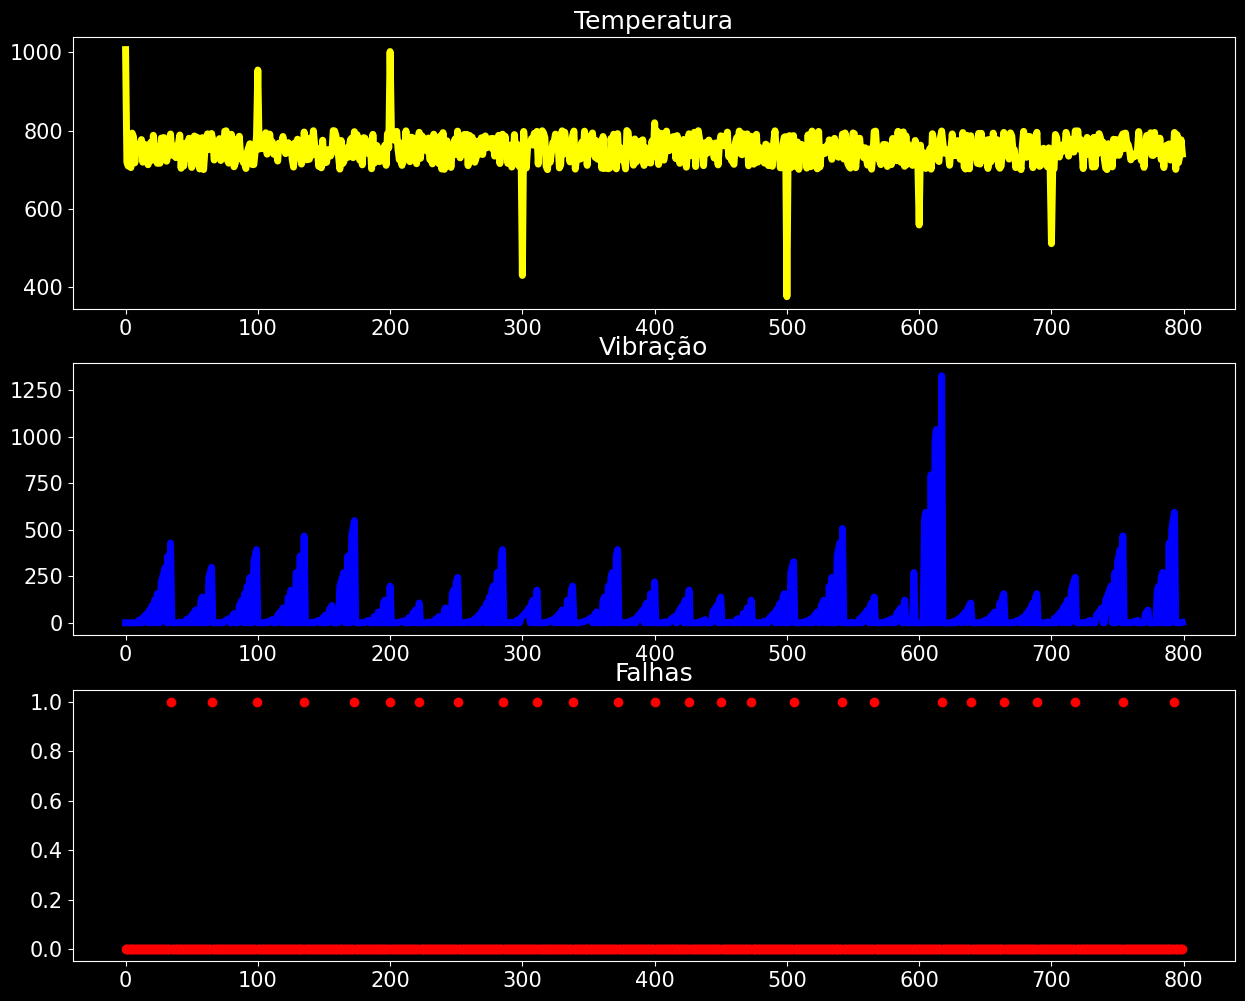

In [8]:
t,v, f = df["temperature"], df["vibration"], df["fail"]
plot_data( t, v, f, 0, 800)

In [9]:
# ==========================================
# STRUCTURAL DATASET INSPECTION
# ==========================================

print("Shape do dataset:", df.shape)
print("\nColunas:")
print(df.columns.tolist())

print("\nTipos das variáveis:")
print(df.dtypes)

print("\nPrimeiras 5 linhas:")
display(df.head())

print("\nÚltimas 5 linhas:")
display(df.tail())

Shape do dataset: (100000, 3)

Colunas:
['temperature', 'vibration', 'fail']

Tipos das variáveis:
temperature    float64
vibration      float64
fail             int64
dtype: object

Primeiras 5 linhas:


,temperature,vibration,fail
0,1006.67,0.01,0
1,719.07,0.08,0
2,709.10,0.00,0
3,726.77,0.00,0
4,705.29,0.00,0



Últimas 5 linhas:


,temperature,vibration,fail
99995,777.39,121.67,0
99996,774.46,0.00,0
99997,788.85,156.25,1
99998,778.62,0.00,0
99999,731.93,0.08,0


In [10]:
# ==========================================
# CONSISTENCY CHECKS
# ==========================================

required_cols = ["temperature", "vibration", "fail"]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Colunas obrigatórias ausentes: {missing_cols}")

print("Todas as colunas obrigatórias foram encontradas.")

print("\nValores ausentes por coluna:")
display(df[required_cols].isna().sum())

print("\nQuantidade de linhas duplicadas:")
print(df.duplicated().sum())

Todas as colunas obrigatórias foram encontradas.

Valores ausentes por coluna:


,0
temperature,0
vibration,0
fail,0



Quantidade de linhas duplicadas:
42762


In [11]:
# ==========================================
# DESCRIPTIVE STATISTICS
# ==========================================

print("Resumo estatístico das variáveis numéricas:")
display(df[["temperature", "vibration", "fail"]].describe())

Resumo estatístico das variáveis numéricas:


,temperature,vibration,fail
count,100000.000000,100000.000000,100000.000000
mean,750.030680,115.140981,0.029590
std,37.026897,452.168741,0.169454
min,312.770000,0.000000,0.000000
25%,724.860000,0.000000,0.000000
50%,750.130000,0.000000,0.000000
75%,775.480000,49.130000,0.000000
max,1188.850000,13676.310000,1.000000


In [12]:
# ==========================================
# TARGET INSPECTION
# ==========================================

print("Distribuição absoluta da variável alvo:")
display(df["fail"].value_counts(dropna=False).sort_index())

print("\nDistribuição relativa da variável alvo:")
display(df["fail"].value_counts(normalize=True, dropna=False).sort_index())

Distribuição absoluta da variável alvo:


,count
fail,
0,97041
1,2959



Distribuição relativa da variável alvo:


,proportion
fail,
0,0.97041
1,0.02959


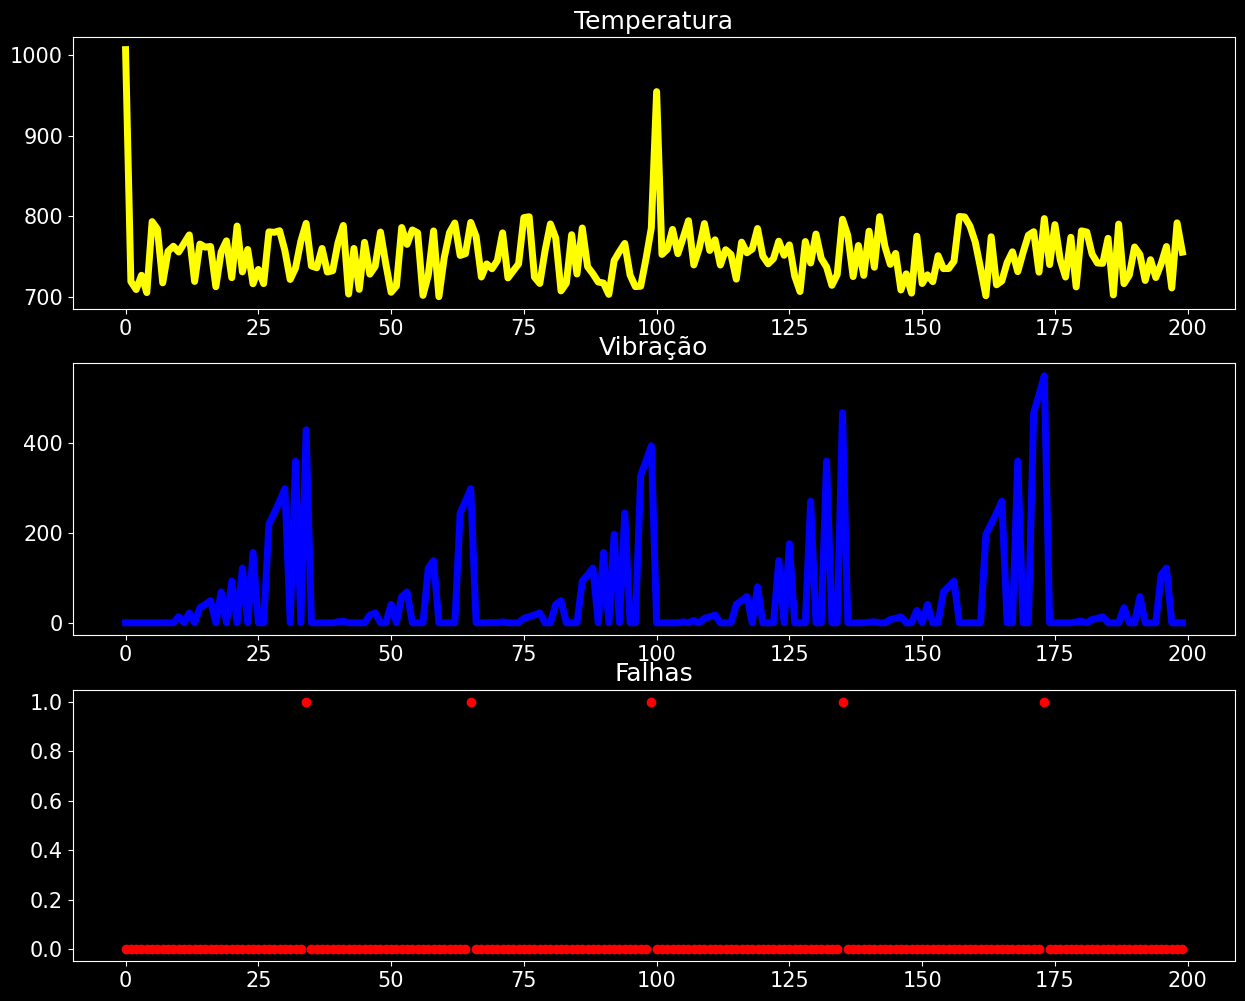

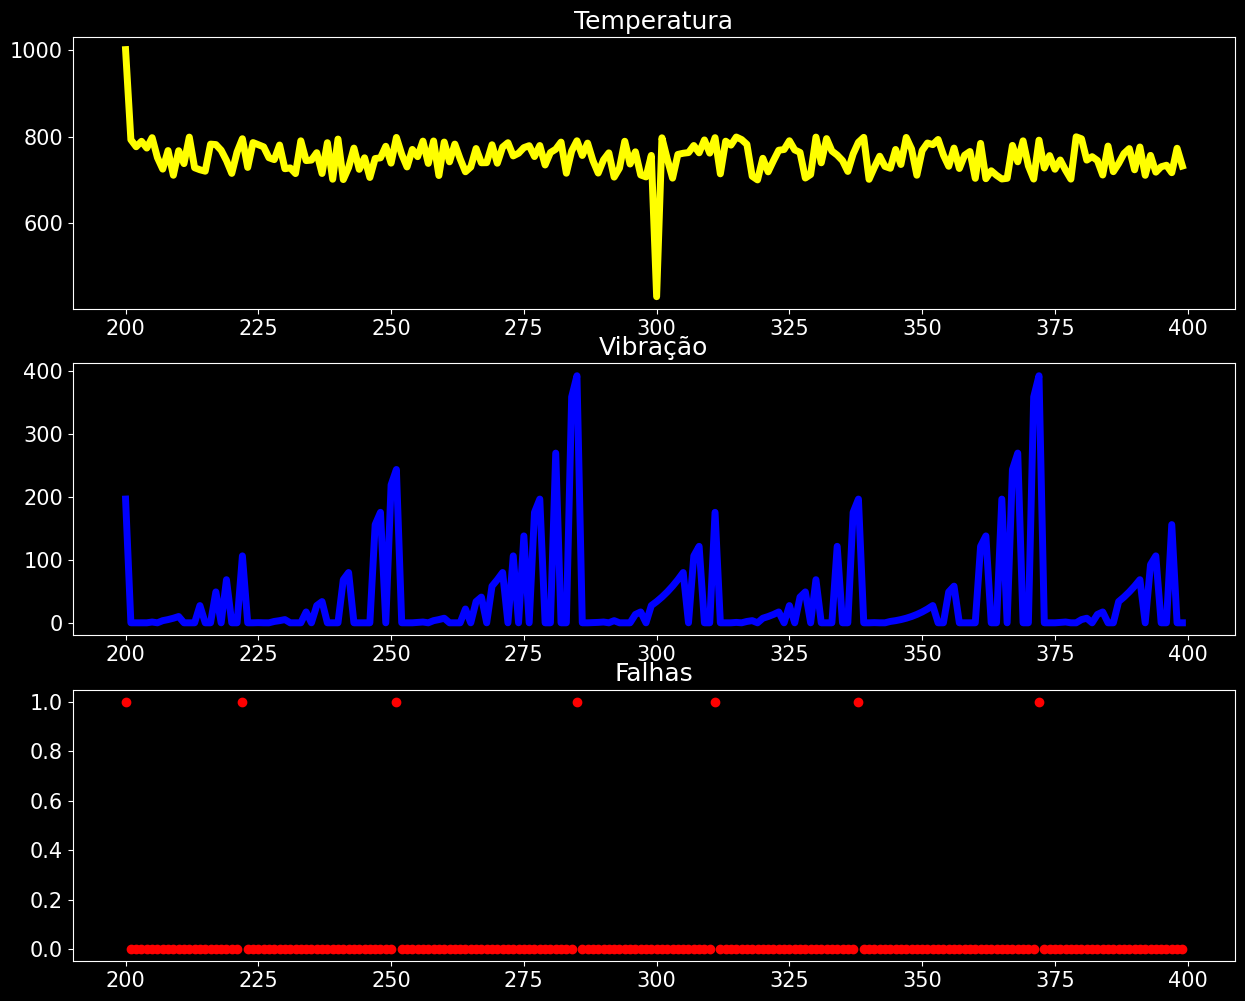

In [13]:
# ==========================================
# SUPPLEMENTARY VISUALIZATION
# Second, shorter visualization to better inspect local failure behavior.
# ==========================================

plot_data(df["temperature"], df["vibration"], df["fail"], 0, 200)
plot_data(df["temperature"], df["vibration"], df["fail"], 200, 400)

The dataset was loaded and inspected for its structure, columns, types, missing values, and duplicates. The three central variables of the study are temperature, vibration, and fail. An initial visual inspection of the signals was also carried out to verify the temporal behavior of the readings and their relationship with failure events, preparing the dataset for the normalization stage and the construction of temporal windows.

## 3.2 Experimental Strategy

In this notebook, data preparation will be carried out with greater methodological rigor.

The main decisions adopted here are:

1. **Temporal split**, without shuffling, to respect the sequential nature of the problem.
2. **Separation gap between training, validation, and test**, reducing leakage between very similar windows.
3. **Normalization based only on training statistics**, avoiding leakage.
4. **Windowing after the temporal split**, better preserving the independence between the sets.

Since this is a predictive maintenance problem with rare events, the subsequent evaluation will place greater emphasis on metrics such as `precision`, `recall`, `F1` for the positive class, and `PR-AUC`, rather than relying only on `accuracy`.


In [14]:
import os
from sklearn.utils.class_weight import compute_class_weight

# ==========================================
# REPRODUCIBILITY AND GENERAL SETTINGS
# ==========================================

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

FEATURE_COLS = ["temperature", "vibration"]
TARGET_COL = "fail"

BACK_LOG = 50
HORIZON = 1

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9, "As proporções devem somar 1."

# Gap to reduce overlap between neighboring windows from different sets
PURGE_GAP = BACK_LOG + HORIZON - 1

EPOCHS = 30
BATCH_SIZE = 32

In [15]:
import os
import json
import shutil
from pathlib import Path

# ==========================================
# EXPERIMENT PERSISTENCE ON DRIVE
# ==========================================

PROJECT_ROOT = Path("/content/drive/MyDrive/projeto_manutencao_preditiva")
EXPERIMENTS_ROOT = PROJECT_ROOT / "experimentos"
EXPERIMENTS_ROOT.mkdir(parents=True, exist_ok=True)

# To completely delete an old experiment, change this to True
FORCE_RESET_EXPERIMENT = False

def make_experiment_paths(experiment_name: str):
    exp_dir = EXPERIMENTS_ROOT / experiment_name

    if FORCE_RESET_EXPERIMENT and exp_dir.exists():
        shutil.rmtree(exp_dir)

    exp_dir.mkdir(parents=True, exist_ok=True)

    paths = {
        "root": exp_dir,
        "backup_dir": exp_dir / "backup_state",
        "best_model_path": exp_dir / "best_model.keras",
        "last_model_path": exp_dir / "last_model.keras",
        "history_csv": exp_dir / "history.csv",
        "metrics_json": exp_dir / "metrics.json",
        "threshold_csv": exp_dir / "thresholds.csv",
        "summary_csv": exp_dir / "summary.csv",
    }
    return paths

def save_json_dict(path, data):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

print("Raiz do projeto:", PROJECT_ROOT)
print("Raiz dos experimentos:", EXPERIMENTS_ROOT)

Raiz do projeto: /content/drive/MyDrive/projeto_manutencao_preditiva
Raiz dos experimentos: /content/drive/MyDrive/projeto_manutencao_preditiva/experimentos


In [16]:
# ==========================================
# CALLBACKS WITH BACKUP AND CHECKPOINTING
# ==========================================

def make_training_callbacks(paths, monitor="val_auc"):
    callbacks = [
        tf.keras.callbacks.BackupAndRestore(
            backup_dir=str(paths["backup_dir"]),
            save_freq="epoch",
            delete_checkpoint=False
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(paths["best_model_path"]),
            monitor=monitor,
            mode="max",
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        ),
        tf.keras.callbacks.CSVLogger(
            filename=str(paths["history_csv"]),
            append=True
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor=monitor,
            mode="max",
            patience=10,
            min_delta=0.001,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        )
    ]
    return callbacks

## 3.3 Temporal Split with Gap

Instead of shuffling the windows, the series will be divided in temporal order into training, validation, and test sets.

In addition, a **gap** will be inserted between the blocks. This gap acts as a “safety buffer” to reduce the chance that two nearly identical windows end up in different sets.


In [17]:
# ==========================================
# TEMPORAL SPLIT ON THE RAW DATAFRAME
# ==========================================

n_total = len(df)

train_end = int(n_total * TRAIN_RATIO)
val_end = int(n_total * (TRAIN_RATIO + VAL_RATIO))

# Temporal blocks with a gap between them
train_slice = slice(0, train_end)
val_slice = slice(train_end + PURGE_GAP, val_end)
test_slice = slice(val_end + PURGE_GAP, n_total)

df_train = df.iloc[train_slice].copy().reset_index(drop=True)
df_val = df.iloc[val_slice].copy().reset_index(drop=True)
df_test = df.iloc[test_slice].copy().reset_index(drop=True)

print("Tamanho total da série:", n_total)
print("PURGE_GAP:", PURGE_GAP)
print("\nTamanhos efetivos após split temporal:")
print("df_train:", df_train.shape)
print("df_val  :", df_val.shape)
print("df_test :", df_test.shape)

assert len(df_train) > BACK_LOG + HORIZON, "Treino ficou pequeno demais para gerar janelas."
assert len(df_val) > BACK_LOG + HORIZON, "Validação ficou pequena demais para gerar janelas."
assert len(df_test) > BACK_LOG + HORIZON, "Teste ficou pequeno demais para gerar janelas."

Tamanho total da série: 100000
PURGE_GAP: 50

Tamanhos efetivos após split temporal:
df_train: (70000, 3)
df_val  : (14950, 3)
df_test : (14950, 3)


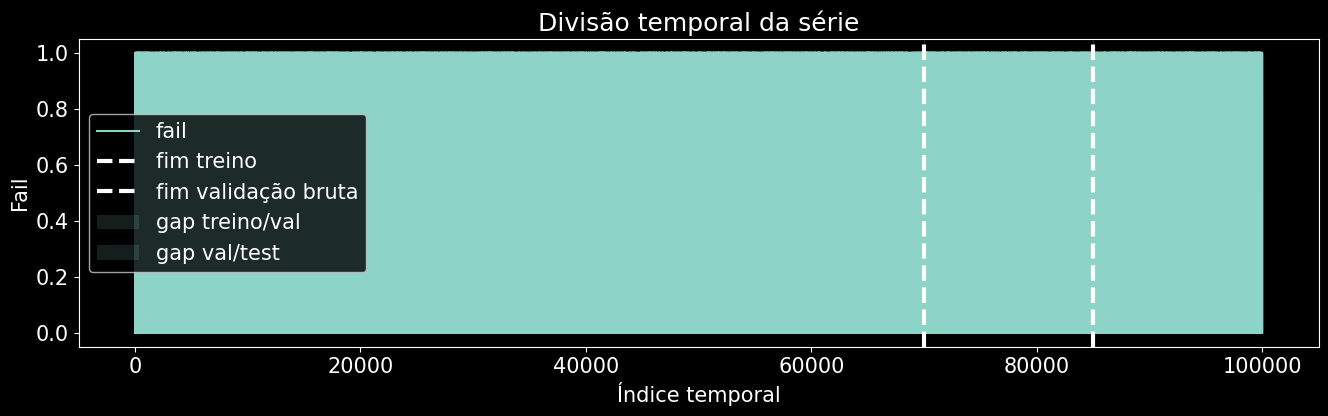

n_total = 100000
train_end = 70000
val_end = 85000
PURGE_GAP = 50

Faixas efetivas:
Treino     : 0 até 69999
Gap 1      : 70000 até 70049
Validação  : 70050 até 84999
Gap 2      : 85000 até 85049
Teste      : 85050 até 99999


In [18]:
# ==========================================
# TEMPORAL BOUNDARY VISUALIZATION
# ==========================================

plt.figure(figsize=(16, 4))
plt.plot(df[TARGET_COL].values, lw=1.5, label="fail")

plt.axvline(train_end, linestyle="--", label="fim treino")
plt.axvline(val_end, linestyle="--", label="fim validação bruta")

plt.axvspan(train_end, min(train_end + PURGE_GAP, n_total - 1), alpha=0.15, label="gap treino/val")
plt.axvspan(val_end, min(val_end + PURGE_GAP, n_total - 1), alpha=0.15, label="gap val/test")

plt.title("Divisão temporal da série")
plt.xlabel("Índice temporal")
plt.ylabel("Fail")
plt.legend()
plt.show()

print("n_total =", n_total)
print("train_end =", train_end)
print("val_end =", val_end)
print("PURGE_GAP =", PURGE_GAP)

print("\nFaixas efetivas:")
print(f"Treino     : 0 até {train_end - 1}")
print(f"Gap 1      : {train_end} até {train_end + PURGE_GAP - 1}")
print(f"Validação  : {train_end + PURGE_GAP} até {val_end - 1}")
print(f"Gap 2      : {val_end} até {val_end + PURGE_GAP - 1}")
print(f"Teste      : {val_end + PURGE_GAP} até {n_total - 1}")

## 3.4 Proper Normalization and Window Creation

The scaler will be fitted **only on the training data** and then applied to the validation and test sets.

Next, each set will be transformed into multivariate temporal windows in the format:

`(n_samples, BACK_LOG, 2)`

where:

* axis 1 = time
* axis 2 = features (`temperature`, `vibration`)

The target will remain the occurrence of failure within the horizon defined by `HORIZON`.


In [19]:
# ==========================================
# WINDOWING FUNCTION
# ==========================================

def build_windows(features_array, target_array, samples, horizon=1):
    X, y = [], []

    max_start = len(features_array) - samples - horizon + 1

    for i in range(max_start):
        x_window = features_array[i : i + samples]
        y_target = target_array[i + samples + horizon - 1]

        X.append(x_window)
        y.append(y_target)

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)

    return X, y

In [20]:
# ==========================================
# NORMALIZATION FITTED ONLY ON THE TRAINING SET
# ==========================================

scaler = MinMaxScaler()

train_features = scaler.fit_transform(df_train[FEATURE_COLS])
val_features = scaler.transform(df_val[FEATURE_COLS])
test_features = scaler.transform(df_test[FEATURE_COLS])

train_target = df_train[TARGET_COL].to_numpy(dtype=np.float32)
val_target = df_val[TARGET_COL].to_numpy(dtype=np.float32)
test_target = df_test[TARGET_COL].to_numpy(dtype=np.float32)

print("Faixas após normalização:")
print("Treino -> min:", train_features.min(), "| max:", train_features.max())
print("Val    -> min:", val_features.min(),   "| max:", val_features.max())
print("Teste  -> min:", test_features.min(),  "| max:", test_features.max())

Faixas após normalização:
Treino -> min: 0.0 | max: 1.0
Val    -> min: 0.0 | max: 0.9781184366724501
Teste  -> min: 0.0 | max: 0.9908341703953979


In [21]:
# ==========================================
# TEMPORAL WINDOW CREATION
# ==========================================

X_train, y_train = build_windows(train_features, train_target, samples=BACK_LOG, horizon=HORIZON)
X_val, y_val = build_windows(val_features, val_target, samples=BACK_LOG, horizon=HORIZON)
X_test, y_test = build_windows(test_features, test_target, samples=BACK_LOG, horizon=HORIZON)

print("Shapes finais:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "| y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)

Shapes finais:
X_train: (69950, 50, 2) | y_train: (69950,)
X_val  : (14900, 50, 2) | y_val  : (14900,)
X_test : (14900, 50, 2) | y_test : (14900,)


In [22]:
# ==========================================
# QUICK WINDOW INSPECTION
# ==========================================

idx = 0

print("Shape de uma janela:", X_train[idx].shape)
print("\nPrimeiros 5 passos da primeira janela:")
print(X_train[idx][:5])

print("\nÚltimos 5 passos da primeira janela:")
print(X_train[idx][-5:])

print("\nAlvo associado:")
print(y_train[idx])

Shape de uma janela: (50, 2)

Primeiros 5 passos da primeira janela:
[[7.9205096e-01 7.3119139e-07]
 [4.6377042e-01 5.8495311e-06]
 [4.5239019e-01 0.0000000e+00]
 [4.7255957e-01 0.0000000e+00]
 [4.4804126e-01 0.0000000e+00]]

Últimos 5 passos da primeira janela:
[[0.5192106  0.        ]
 [0.47413477 0.0012635 ]
 [0.48519543 0.00160643]
 [0.5337526  0.        ]
 [0.48873392 0.        ]]

Alvo associado:
0.0


In [23]:
# ==========================================
# CLASS DISTRIBUTION
# ==========================================

def show_class_distribution(name, y):
    unique, counts = np.unique(y.astype(int), return_counts=True)
    print(f"\nDistribuição de classes em {name}:")
    for cls, count in zip(unique, counts):
        print(f"Classe {cls}: {count} amostras ({count / len(y):.2%})")

show_class_distribution("y_train", y_train)
show_class_distribution("y_val", y_val)
show_class_distribution("y_test", y_test)


Distribuição de classes em y_train:
Classe 0: 67894 amostras (97.06%)
Classe 1: 2056 amostras (2.94%)

Distribuição de classes em y_val:
Classe 0: 14448 amostras (96.97%)
Classe 1: 452 amostras (3.03%)

Distribuição de classes em y_test:
Classe 0: 14456 amostras (97.02%)
Classe 1: 444 amostras (2.98%)


In [24]:
# ==========================================
# CLASS WEIGHTS CALCULATED ONLY ON THE TRAINING SET
# ==========================================

classes = np.unique(y_train.astype(int))

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train.astype(int)
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_values)
}

print("Class weights:")
print(class_weights)

Class weights:
{0: 0.5151412495949569, 1: 17.011186770428015}


### Closing the Preparation Stage

At this point, the pipeline already includes:

* temporal separation between training, validation, and test sets;
* a gap between blocks to reduce contamination between windows;
* normalization fitted exclusively on the training set;
* multivariate temporal windows in the correct format;
* class weights calculated only on the training set.

From this point onward, the models should be trained using:

* `X_train, y_train` for training
* `validation_data=(X_val, y_val)` for validation
* `X_test, y_test` only for final evaluation


## 4.1 LSTM with Clean Temporal Validation

At this stage, the LSTM will be trained using:

* `X_train, y_train` for training
* `validation_data=(X_val, y_val)` for validation
* `X_test, y_test` **will not be used yet**

This allows training adjustments and threshold selection to be made without contaminating the final test evaluation.


In [44]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)
import seaborn as sns

In [25]:
# ==========================================
# FUNCTION TO CREATE THE LSTM
# ==========================================

def build_lstm_model(input_shape, learning_rate=1e-4, lstm_units=50, dropout_rate=0.2):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(lstm_units),
        Dropout(dropout_rate),
        Dense(1, activation="sigmoid")
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [26]:
# ==========================================
# CALLBACKS
# ==========================================

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

In [27]:
# ==========================================
# CNN-SPECIFIC CALLBACKS
# ==========================================

callbacks_cnn = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=10,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

In [29]:
# ==========================================
# LSTM TRAINING WITH BACKUP/RESTORE
# ==========================================

tf.keras.backend.clear_session()

LSTM_EXPERIMENT_NAME = "baseline_lstm_h1"
lstm_paths = make_experiment_paths(LSTM_EXPERIMENT_NAME)
callbacks_lstm = make_training_callbacks(lstm_paths, monitor="val_auc")

LSTM_Model = build_lstm_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    learning_rate=1e-4,
    lstm_units=50,
    dropout_rate=0.2
)

LSTM_Model.summary()

history_lstm = LSTM_Model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    callbacks=callbacks_lstm,
    verbose=1
)

# also saves the final version from the current session
LSTM_Model.save(str(lstm_paths["last_model_path"]))

print("Treino LSTM finalizado.")
print("Melhor modelo salvo em:", lstm_paths["best_model_path"])
print("Último modelo salvo em:", lstm_paths["last_model_path"])
print("Histórico salvo em:", lstm_paths["history_csv"])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,651 (41.61 KB)

 Trainable params: 10,651 (41.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2186/2186 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3614 - auc: 0.4999 - loss: 0.6994 - precision: 0.0295 - recall: 0.6377
Epoch 1: val_auc improved from None to 0.52651, saving model to /content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/baseline_lstm_h1/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/baseline_lstm_h1/best_model.keras
2186/2186 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - accuracy: 0.4508 - auc: 0.5022 - loss: 0.6933 - precision: 0.0288 - recall: 0.5399 - val_accuracy: 0.9541 - val_auc: 0.5265 - val_loss: 0.6827 - val_precision: 0.0504 - val_recall: 0.0288 - learning_rate: 1.0000e-04
Epoch 2/30
2183/2186 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5867 - auc: 0.5204 - loss: 0.6986 - precision: 0.0338 - recall: 0.4604
Epoch 2: val_auc improved from 0.52651 to 0.56014, saving model to /content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/baseline_lstm_h1/best_model.ker

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
25,0.601530,0.711250,0.608344,0.051741,0.724708,0.604094,0.725711,0.617139,0.055202,0.747788,1.562500e-06
26,0.602745,0.711948,0.608004,0.051270,0.714981,0.603758,0.726028,0.617062,0.055592,0.754425,1.000000e-06
27,0.597999,0.706632,0.610957,0.050714,0.715467,0.601342,0.725879,0.619303,0.055412,0.756637,1.000000e-06
28,0.598599,0.705307,0.611961,0.050290,0.707685,0.600940,0.726313,0.619259,0.055645,0.761062,1.000000e-06
29,0.597898,0.711038,0.608581,0.051166,0.722763,0.602282,0.726319,0.617598,0.055393,0.754425,1.000000e-06


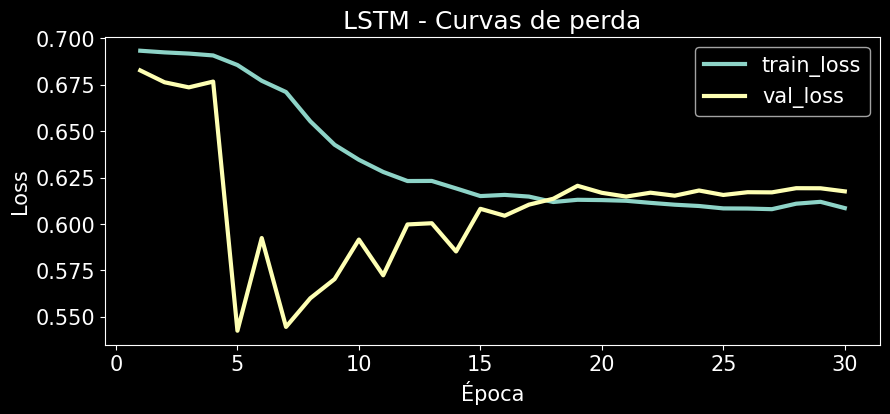

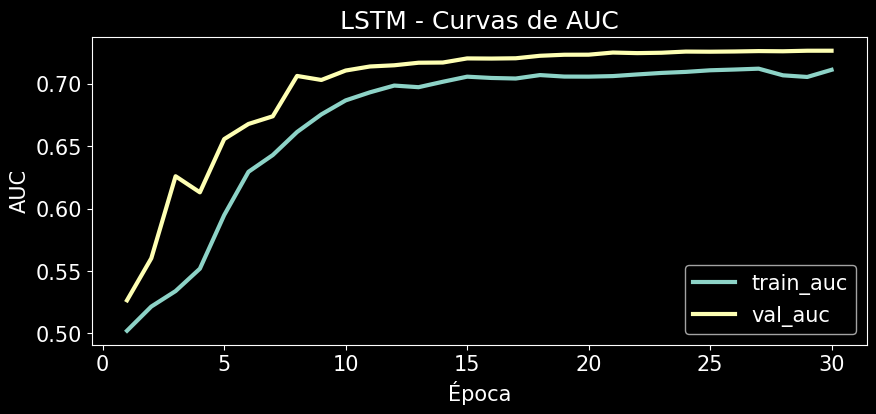

In [30]:
# ==========================================
# TRAINING CURVES
# ==========================================

history_df = pd.DataFrame(history_lstm.history)
display(history_df.tail())

plt.figure(figsize=(10, 4))
plt.plot(history_df.index + 1, history_df["loss"], label="train_loss")
plt.plot(history_df.index + 1, history_df["val_loss"], label="val_loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("LSTM - Curvas de perda")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_df.index + 1, history_df["auc"], label="train_auc")
plt.plot(history_df.index + 1, history_df["val_auc"], label="val_auc")
plt.xlabel("Época")
plt.ylabel("AUC")
plt.title("LSTM - Curvas de AUC")
plt.legend()
plt.show()

In [28]:
# ==========================================
# LOAD BASELINES FROM DRIVE (WITHOUT RETRAINING)
# ==========================================

tf.keras.backend.clear_session()

lstm_paths = make_experiment_paths("baseline_lstm_h1")
cnn_paths = make_experiment_paths("baseline_cnn_h1")

LSTM_Model = tf.keras.models.load_model(str(lstm_paths["best_model_path"]))
CNN1D_Model = tf.keras.models.load_model(str(cnn_paths["best_model_path"]))

print("LSTM carregada de:", lstm_paths["best_model_path"])
print("CNN 1D carregada de:", cnn_paths["best_model_path"])

LSTM carregada de: /content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/baseline_lstm_h1/best_model.keras
CNN 1D carregada de: /content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/baseline_cnn_h1/best_model.keras


In [29]:
# ==========================================
# EVALUATION FUNCTION
# ==========================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

def evaluate_model(model, X, y, dataset_name="dataset", threshold=0.5, batch_size=32):
    # 1) Keep only the loss from Keras evaluate
    eval_dict = model.evaluate(X, y, batch_size=batch_size, verbose=0, return_dict=True)
    loss_value = float(eval_dict["loss"])

    # 2) Continuous scores
    y_score = model.predict(X, batch_size=batch_size, verbose=0).ravel()

    # 3) Binary prediction using the selected threshold
    y_true = y.astype(int)
    y_pred = (y_score >= threshold).astype(int)

    # 4) Threshold-dependent metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision_classe_1 = precision_score(y_true, y_pred, zero_division=0)
    recall_classe_1 = recall_score(y_true, y_pred, zero_division=0)
    f1_classe_1 = f1_score(y_true, y_pred, zero_division=0)

    # 5) Threshold-independent metrics
    roc_auc = roc_auc_score(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)

    # 6) Text report
    print(f"\n{'='*60}")
    print(f"AVALIAÇÃO - {dataset_name} | threshold={threshold}")
    print(f"{'='*60}")

    print("\nMétricas principais:")
    metrics_series = pd.Series({
        "loss": loss_value,
        "accuracy": accuracy,
        "precision_classe_1": precision_classe_1,
        "recall_classe_1": recall_classe_1,
        "f1_classe_1": f1_classe_1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    })
    print(metrics_series)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de Confusão - {dataset_name}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()

    result = {
        "dataset": dataset_name,
        "threshold": float(threshold),
        "loss": loss_value,
        "accuracy": float(accuracy),
        "precision_classe_1": float(precision_classe_1),
        "recall_classe_1": float(recall_classe_1),
        "f1_classe_1": float(f1_classe_1),
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc)
    }

    return result, y_score

In [30]:
# ==========================================
# EVALUATION ON THE VALIDATION SET
# ==========================================

lstm_val_result_05, y_score_val_lstm = evaluate_model(
    model=LSTM_Model,
    X=X_val,
    y=y_val,
    dataset_name="Validação - LSTM",
    threshold=0.5,
    batch_size=BATCH_SIZE
)

display(pd.DataFrame([lstm_val_result_05]))


AVALIAÇÃO - Validação - LSTM | threshold=0.5

Métricas principais:
loss                  0.617598
accuracy              0.602282
precision_classe_1    0.055393
recall_classe_1       0.754425
f1_classe_1           0.103208
roc_auc               0.726311
pr_auc                0.057380
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.9873    0.5975    0.7445     14448
           1     0.0554    0.7544    0.1032       452

    accuracy                         0.6023     14900
   macro avg     0.5213    0.6760    0.4238     14900
weighted avg     0.9590    0.6023    0.7250     14900



NameError: name 'sns' is not defined

<Figure size 600x500 with 0 Axes>

### Threshold Selection on the Validation Set

Since the positive class is rare, the default threshold of `0.5` may not be the best operating point.

At this stage, the threshold will be tested **only on the validation set**, preserving the test set for the final comparison between architectures.


In [31]:
# ==========================================
# THRESHOLD SWEEP ON THE VALIDATION SET
# ==========================================

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for th in thresholds:
    y_pred_th = (y_score_val_lstm >= th).astype(int)

    threshold_results.append({
        "threshold": round(float(th), 2),
        "precision_classe_1": precision_score(y_val, y_pred_th, zero_division=0),
        "recall_classe_1": recall_score(y_val, y_pred_th, zero_division=0),
        "f1_classe_1": f1_score(y_val, y_pred_th, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

NameError: name 'y_score_val_lstm' is not defined

In [34]:
# ==========================================
# SELECT THE BEST THRESHOLD
# current criterion: highest positive-class F1 on the validation set
# ==========================================

best_idx = threshold_df["f1_classe_1"].idxmax()
BEST_THRESHOLD_LSTM = float(threshold_df.loc[best_idx, "threshold"])

print("Melhor threshold da LSTM na validação:", BEST_THRESHOLD_LSTM)

display(
    threshold_df.sort_values(
        by=["f1_classe_1", "recall_classe_1", "precision_classe_1"],
        ascending=False
    ).head(10)
)

Melhor threshold da LSTM na validação: 0.6


,threshold,precision_classe_1,recall_classe_1,f1_classe_1
10,0.60,0.060034,0.471239,0.106500
9,0.55,0.057771,0.621681,0.105719
11,0.65,0.061860,0.320796,0.103720
8,0.50,0.055592,0.754425,0.103553
7,0.45,0.051741,0.831858,0.097422
6,0.40,0.049258,0.902655,0.093417
5,0.35,0.046416,0.946903,0.088494
12,0.70,0.056054,0.165929,0.083799
4,0.30,0.043380,0.977876,0.083075
3,0.25,0.039695,0.988938,0.076325



AVALIAÇÃO - Validação - LSTM (melhor threshold) | threshold=0.6

Métricas principais:
loss                  0.617062
accuracy              0.760134
precision_classe_1    0.060034
recall_classe_1       0.471239
f1_classe_1           0.106500
roc_auc               0.726025
pr_auc                0.057329
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.9789    0.7692    0.8615     14448
           1     0.0600    0.4712    0.1065       452

    accuracy                         0.7601     14900
   macro avg     0.5195    0.6202    0.4840     14900
weighted avg     0.9511    0.7601    0.8386     14900



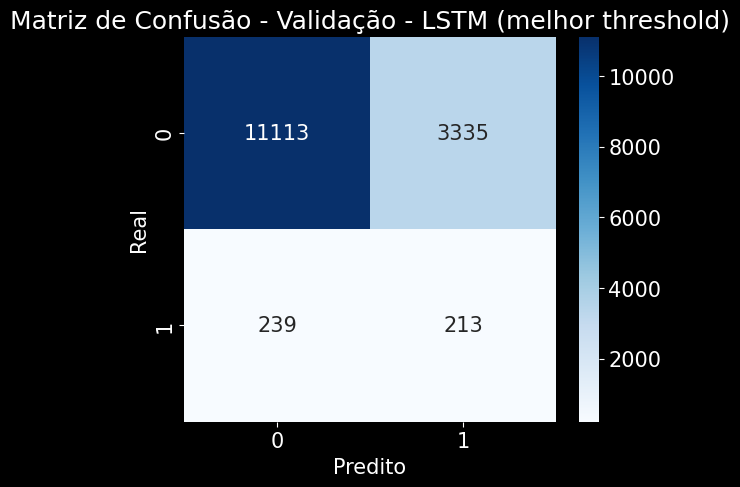

,dataset,threshold,loss,accuracy,precision_classe_1,recall_classe_1,f1_classe_1,roc_auc,pr_auc
0,Validação - LSTM (melhor threshold),0.6,0.617062,0.760134,0.060034,0.471239,0.1065,0.726025,0.057329


In [35]:
# ==========================================
# REEVALUATE THE LSTM ON THE VALIDATION SET
# WITH THE BEST THRESHOLD
# ==========================================

lstm_val_result_best, _ = evaluate_model(
    model=LSTM_Model,
    X=X_val,
    y=y_val,
    dataset_name="Validação - LSTM (melhor threshold)",
    threshold=BEST_THRESHOLD_LSTM,
    batch_size=BATCH_SIZE
)

display(pd.DataFrame([lstm_val_result_best]))

At this point, the LSTM has already been:

trained with clean temporal validation;
monitored with EarlyStopping and ReduceLROnPlateau;
evaluated on the validation set using metrics more suitable for a rare class;
calibrated by threshold without using the test set.

The next natural step will be to repeat the same logic for the 1D CNN, allowing a fairer comparison between architectures.

## 4.2 1D CNN with Clean Temporal Validation

At this stage, the 1D CNN will be trained under the same protocol as the LSTM:

* `X_train, y_train` for training
* `validation_data=(X_val, y_val)` for validation
* `X_test, y_test` still reserved for final evaluation

The comparison between architectures will be carried out after both have undergone:

* training under the same pipeline;
* evaluation on the validation set;
* threshold calibration only on the validation set.


In [36]:
# Reset state function

tf.keras.backend.clear_session()

In [32]:
# ==========================================
# FUNCTION TO CREATE THE 1D CNN
# ==========================================

def build_cnn1d_model(input_shape, learning_rate=1e-4, filters=64, kernel_size=3, dropout_rate=0.2):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(filters=filters, kernel_size=kernel_size, activation="relu"),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dropout(dropout_rate),
        Dense(1, activation="sigmoid")
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [38]:
# ==========================================
# 1D CNN TRAINING WITH BACKUP/RESTORE
# ==========================================

tf.keras.backend.clear_session()

CNN_EXPERIMENT_NAME = "baseline_cnn_h1"
cnn_paths = make_experiment_paths(CNN_EXPERIMENT_NAME)
callbacks_cnn = make_training_callbacks(cnn_paths, monitor="val_auc")

CNN1D_Model = build_cnn1d_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    learning_rate=1e-4,
    filters=64,
    kernel_size=3,
    dropout_rate=0.2
)

CNN1D_Model.summary()

history_cnn = CNN1D_Model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    callbacks=callbacks_cnn,
    verbose=1
)

CNN1D_Model.save(str(cnn_paths["last_model_path"]))

print("Treino CNN finalizado.")
print("Melhor modelo salvo em:", cnn_paths["best_model_path"])
print("Último modelo salvo em:", cnn_paths["last_model_path"])
print("Histórico salvo em:", cnn_paths["history_csv"])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 48, 64)         │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,537 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,985 (7.75 KB)

 Trainable params: 1,985 (7.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2186/2186 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3128 - auc: 0.4997 - loss: 0.6998 - precision: 0.0298 - recall: 0.6967
Epoch 1: val_auc improved from None to 0.59457, saving model to /content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/baseline_cnn_h1/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/baseline_cnn_h1/best_model.keras
2186/2186 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.4472 - auc: 0.5008 - loss: 0.6937 - precision: 0.0293 - recall: 0.5550 - val_accuracy: 0.9696 - val_auc: 0.5946 - val_loss: 0.6678 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/30
2177/2186 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5511 - auc: 0.5121 - loss: 0.6990 - precision: 0.0307 - recall: 0.4549
Epoch 2: val_auc improved from 0.59457 to 0.62911, saving model to /content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/baseline_cnn_h1/best_mode

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
25,0.629164,0.736761,0.611672,0.057179,0.750000,0.651544,0.756439,0.603717,0.062731,0.752212,0.000050
26,0.629264,0.737732,0.609610,0.056668,0.742218,0.648792,0.756666,0.604581,0.062740,0.758850,0.000050
27,0.629350,0.738555,0.609135,0.056845,0.744650,0.642148,0.756368,0.608914,0.062096,0.765487,0.000025
28,0.630107,0.739653,0.607816,0.057187,0.748055,0.642953,0.756526,0.607570,0.062230,0.765487,0.000025
29,0.628578,0.738631,0.608449,0.057354,0.753891,0.642685,0.756677,0.607228,0.062028,0.763274,0.000025


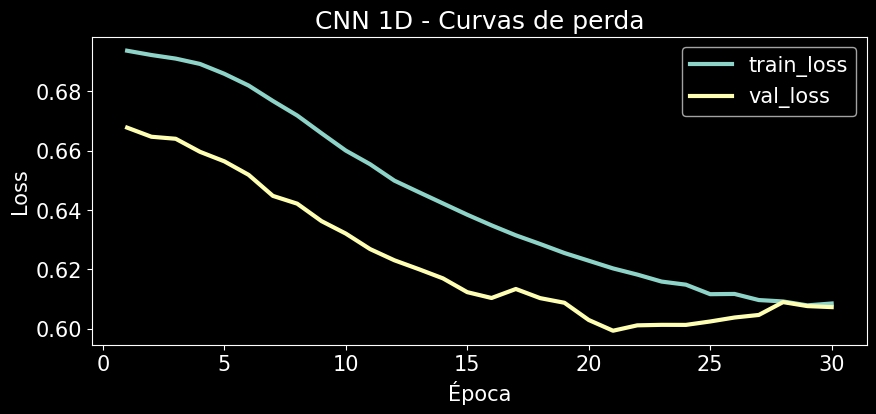

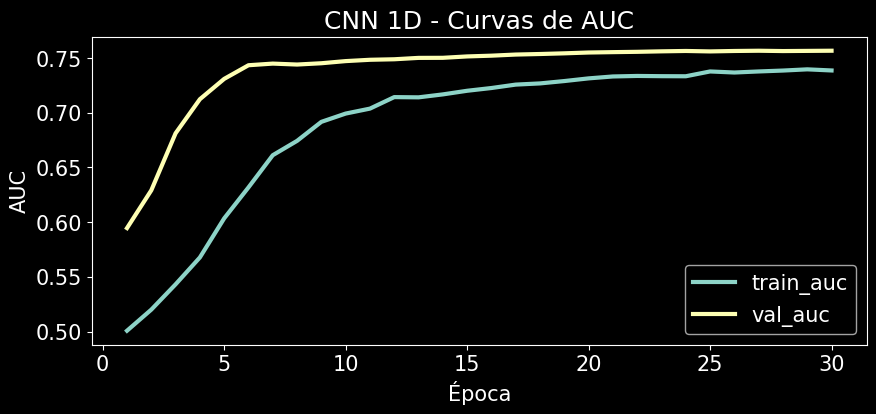

In [39]:
# ==========================================
# TRAINING CURVES - CNN
# ==========================================

history_cnn_df = pd.DataFrame(history_cnn.history)
display(history_cnn_df.tail())

plt.figure(figsize=(10, 4))
plt.plot(history_cnn_df.index + 1, history_cnn_df["loss"], label="train_loss")
plt.plot(history_cnn_df.index + 1, history_cnn_df["val_loss"], label="val_loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("CNN 1D - Curvas de perda")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_cnn_df.index + 1, history_cnn_df["auc"], label="train_auc")
plt.plot(history_cnn_df.index + 1, history_cnn_df["val_auc"], label="val_auc")
plt.xlabel("Época")
plt.ylabel("AUC")
plt.title("CNN 1D - Curvas de AUC")
plt.legend()
plt.show()

In [33]:
# ==========================================
# CNN EVALUATION ON THE VALIDATION SET
# ==========================================

cnn_val_result_05, y_score_val_cnn = evaluate_model(
    model=CNN1D_Model,
    X=X_val,
    y=y_val,
    dataset_name="Validação - CNN 1D",
    threshold=0.5,
    batch_size=BATCH_SIZE
)

display(pd.DataFrame([cnn_val_result_05]))


AVALIAÇÃO - Validação - CNN 1D | threshold=0.5

Métricas principais:
loss                  0.607228
accuracy              0.642685
precision_classe_1    0.062028
recall_classe_1       0.763274
f1_classe_1           0.114732
roc_auc               0.756704
pr_auc                0.067084
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.9885    0.6389    0.7762     14448
           1     0.0620    0.7633    0.1147       452

    accuracy                         0.6427     14900
   macro avg     0.5253    0.7011    0.4455     14900
weighted avg     0.9604    0.6427    0.7561     14900



NameError: name 'sns' is not defined

<Figure size 600x500 with 0 Axes>

### CNN Threshold Selection on the Validation Set

As with the LSTM, the CNN threshold will be calibrated only on the validation set, using the positive-class `F1` score as the main criterion.


In [41]:
# ==========================================
# THRESHOLD SWEEP - CNN ON THE VALIDATION SET
# ==========================================

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results_cnn = []

for th in thresholds:
    y_pred_th = (y_score_val_cnn >= th).astype(int)

    threshold_results_cnn.append({
        "threshold": round(float(th), 2),
        "precision_classe_1": precision_score(y_val, y_pred_th, zero_division=0),
        "recall_classe_1": recall_score(y_val, y_pred_th, zero_division=0),
        "f1_classe_1": f1_score(y_val, y_pred_th, zero_division=0)
    })

threshold_cnn_df = pd.DataFrame(threshold_results_cnn)
display(threshold_cnn_df)

,threshold,precision_classe_1,recall_classe_1,f1_classe_1
0,0.10,0.031170,1.000000,0.060456
1,0.15,0.031831,1.000000,0.061698
2,0.20,0.032657,0.997788,0.063245
3,0.25,0.034210,0.995575,0.066147
4,0.30,0.037062,0.991150,0.071451
5,0.35,0.042134,0.980088,0.080795
6,0.40,0.050035,0.962389,0.095124
7,0.45,0.057722,0.907080,0.108537
8,0.50,0.062559,0.734513,0.115298
9,0.55,0.064212,0.482301,0.113335


In [42]:
# ==========================================
# SELECT THE BEST CNN THRESHOLD
# ==========================================

best_idx_cnn = threshold_cnn_df["f1_classe_1"].idxmax()
BEST_THRESHOLD_CNN = float(threshold_cnn_df.loc[best_idx_cnn, "threshold"])

print("Melhor threshold da CNN na validação:", BEST_THRESHOLD_CNN)

display(
    threshold_cnn_df.sort_values(
        by=["f1_classe_1", "recall_classe_1", "precision_classe_1"],
        ascending=False
    ).head(10)
)

Melhor threshold da CNN na validação: 0.5


,threshold,precision_classe_1,recall_classe_1,f1_classe_1
8,0.50,0.062559,0.734513,0.115298
9,0.55,0.064212,0.482301,0.113335
10,0.60,0.068303,0.283186,0.110060
7,0.45,0.057722,0.907080,0.108537
11,0.65,0.076747,0.148230,0.101132
6,0.40,0.050035,0.962389,0.095124
5,0.35,0.042134,0.980088,0.080795
4,0.30,0.037062,0.991150,0.071451
3,0.25,0.034210,0.995575,0.066147
12,0.70,0.066210,0.064159,0.065169



AVALIAÇÃO - Validação - CNN 1D (melhor threshold) | threshold=0.5

Métricas principais:
loss                  0.601227
accuracy              0.658054
precision_classe_1    0.062559
recall_classe_1       0.734513
f1_classe_1           0.115298
roc_auc               0.756338
pr_auc                0.066557
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.9875    0.6557    0.7881     14448
           1     0.0626    0.7345    0.1153       452

    accuracy                         0.6581     14900
   macro avg     0.5250    0.6951    0.4517     14900
weighted avg     0.9594    0.6581    0.7677     14900



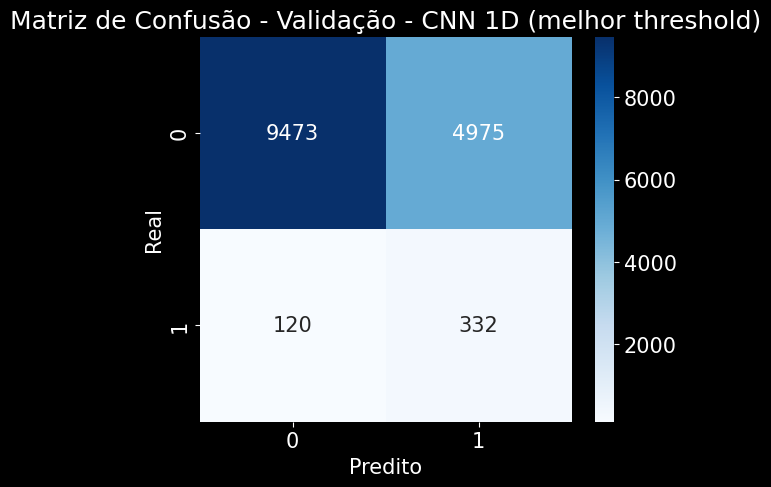

,dataset,threshold,loss,accuracy,precision_classe_1,recall_classe_1,f1_classe_1,roc_auc,pr_auc
0,Validação - CNN 1D (melhor threshold),0.5,0.601227,0.658054,0.062559,0.734513,0.115298,0.756338,0.066557


In [43]:
# ==========================================
# REEVALUATE THE CNN WITH THE BEST THRESHOLD
# ==========================================

cnn_val_result_best, _ = evaluate_model(
    model=CNN1D_Model,
    X=X_val,
    y=y_val,
    dataset_name="Validação - CNN 1D (melhor threshold)",
    threshold=BEST_THRESHOLD_CNN,
    batch_size=BATCH_SIZE
)

display(pd.DataFrame([cnn_val_result_best]))

### Closing the CNN Stage

At this point, the 1D CNN will have been:

* trained with clean temporal validation;
* calibrated by threshold only on the validation set;
* prepared for a fair comparison with the LSTM.

In the next step, it will be possible to build a structured comparison between the two architectures on the validation set and, only after that, carry out the final evaluation on the test set.


## 4.3 Comparison Between Architectures on the Validation Set

At this point, both the LSTM and the 1D CNN have already been:

* trained with a temporal split;
* evaluated on the validation set;
* calibrated by threshold only on the validation set.

Thus, the comparison below is methodologically fairer than the one made in the submitted notebook, since the test set still remains preserved.


In [44]:
# ==========================================
# LSTM VS CNN COMPARISON ON THE VALIDATION SET
# ==========================================

comparison_val_df = pd.DataFrame([
    lstm_val_result_05,
    lstm_val_result_best,
    cnn_val_result_05,
    cnn_val_result_best
])

display(
    comparison_val_df[[
        "dataset",
        "threshold",
        "accuracy",
        "precision_classe_1",
        "recall_classe_1",
        "f1_classe_1",
        "roc_auc",
        "pr_auc"
    ]].sort_values(
        by=["f1_classe_1", "pr_auc", "roc_auc"],
        ascending=False
    )
)

,dataset,threshold,accuracy,precision_classe_1,recall_classe_1,f1_classe_1,roc_auc,pr_auc
2,Validação - CNN 1D,0.5,0.658054,0.062559,0.734513,0.115298,0.756338,0.066557
3,Validação - CNN 1D (melhor threshold),0.5,0.658054,0.062559,0.734513,0.115298,0.756338,0.066557
1,Validação - LSTM (melhor threshold),0.6,0.760134,0.060034,0.471239,0.106500,0.726025,0.057329
0,Validação - LSTM,0.5,0.603758,0.055592,0.754425,0.103553,0.726025,0.057329


In [45]:
# ==========================================
# CONCISE VALIDATION SUMMARY
# ==========================================

summary_val_df = pd.DataFrame([
    {
        "modelo": "LSTM",
        "threshold_escolhido": BEST_THRESHOLD_LSTM,
        "precision_classe_1": lstm_val_result_best["precision_classe_1"],
        "recall_classe_1": lstm_val_result_best["recall_classe_1"],
        "f1_classe_1": lstm_val_result_best["f1_classe_1"],
        "roc_auc": lstm_val_result_best["roc_auc"],
        "pr_auc": lstm_val_result_best["pr_auc"]
    },
    {
        "modelo": "CNN 1D",
        "threshold_escolhido": BEST_THRESHOLD_CNN,
        "precision_classe_1": cnn_val_result_best["precision_classe_1"],
        "recall_classe_1": cnn_val_result_best["recall_classe_1"],
        "f1_classe_1": cnn_val_result_best["f1_classe_1"],
        "roc_auc": cnn_val_result_best["roc_auc"],
        "pr_auc": cnn_val_result_best["pr_auc"]
    }
])

display(summary_val_df.sort_values(by=["f1_classe_1", "pr_auc"], ascending=False))

,modelo,threshold_escolhido,precision_classe_1,recall_classe_1,f1_classe_1,roc_auc,pr_auc
1,CNN 1D,0.5,0.062559,0.734513,0.115298,0.756338,0.066557
0,LSTM,0.6,0.060034,0.471239,0.106500,0.726025,0.057329


### Interpretation of the Validation Set

The main architecture choice will be made based on the validation set, prioritizing:

1. positive-class `F1`
2. `PR-AUC`
3. `ROC-AUC`

Since the failure class is rare, this criterion is more informative than `accuracy` in isolation.


In [46]:
# ==========================================
# SELECT THE FINAL ARCHITECTURE
# main criterion: highest positive-class F1 on the validation set
# ==========================================

if cnn_val_result_best["f1_classe_1"] > lstm_val_result_best["f1_classe_1"]:
    FINAL_MODEL_NAME = "CNN 1D"
    FINAL_MODEL = CNN1D_Model
    FINAL_THRESHOLD = BEST_THRESHOLD_CNN
else:
    FINAL_MODEL_NAME = "LSTM"
    FINAL_MODEL = LSTM_Model
    FINAL_THRESHOLD = BEST_THRESHOLD_LSTM

print("Arquitetura escolhida para avaliação final no teste:", FINAL_MODEL_NAME)
print("Threshold final escolhido na validação:", FINAL_THRESHOLD)

Arquitetura escolhida para avaliação final no teste: CNN 1D
Threshold final escolhido na validação: 0.5


## 5. Final Evaluation on the Test Set

From this point onward, the test set will be used for the first time.

Important:

* the threshold used on the test set was previously chosen on the validation set;
* no recalibration will be performed on the test set;
* this stage represents the cleanest final evaluation in the notebook.



AVALIAÇÃO - Teste - CNN 1D | threshold=0.5

Métricas principais:
loss                  0.600286
accuracy              0.653423
precision_classe_1    0.058383
recall_classe_1       0.702703
f1_classe_1           0.107809
roc_auc               0.737530
pr_auc                0.061130
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.9862    0.6519    0.7849     14456
           1     0.0584    0.7027    0.1078       444

    accuracy                         0.6534     14900
   macro avg     0.5223    0.6773    0.4464     14900
weighted avg     0.9585    0.6534    0.7648     14900



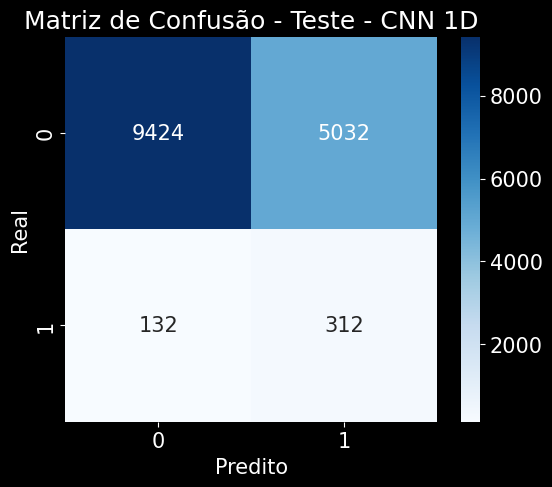

,dataset,threshold,loss,accuracy,precision_classe_1,recall_classe_1,f1_classe_1,roc_auc,pr_auc
0,Teste - CNN 1D,0.5,0.600286,0.653423,0.058383,0.702703,0.107809,0.73753,0.06113


In [47]:
# ==========================================
# FINAL EVALUATION OF THE SELECTED MODEL ON THE TEST SET
# ==========================================

final_test_result, y_score_test_final = evaluate_model(
    model=FINAL_MODEL,
    X=X_test,
    y=y_test,
    dataset_name=f"Teste - {FINAL_MODEL_NAME}",
    threshold=FINAL_THRESHOLD,
    batch_size=BATCH_SIZE
)

display(pd.DataFrame([final_test_result]))


AVALIAÇÃO - Teste - LSTM | threshold=0.6

Métricas principais:
loss                  0.617593
accuracy              0.771342
precision_classe_1    0.055772
recall_classe_1       0.418919
f1_classe_1           0.098439
roc_auc               0.708308
pr_auc                0.053308
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.9777    0.7822    0.8691     14456
           1     0.0558    0.4189    0.0984       444

    accuracy                         0.7713     14900
   macro avg     0.5167    0.6005    0.4838     14900
weighted avg     0.9502    0.7713    0.8461     14900



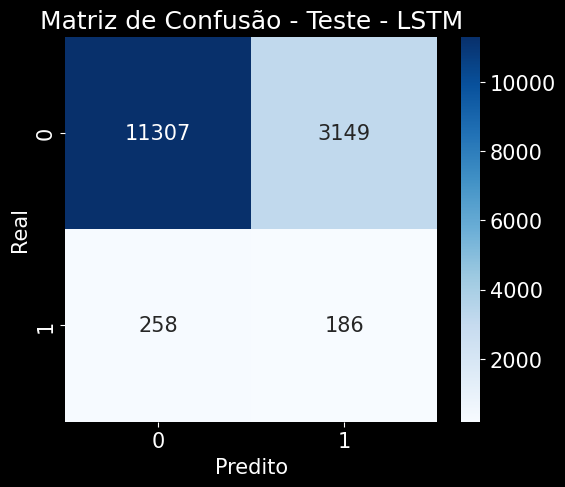


AVALIAÇÃO - Teste - CNN 1D | threshold=0.5

Métricas principais:
loss                  0.600286
accuracy              0.653423
precision_classe_1    0.058383
recall_classe_1       0.702703
f1_classe_1           0.107809
roc_auc               0.737530
pr_auc                0.061130
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.9862    0.6519    0.7849     14456
           1     0.0584    0.7027    0.1078       444

    accuracy                         0.6534     14900
   macro avg     0.5223    0.6773    0.4464     14900
weighted avg     0.9585    0.6534    0.7648     14900



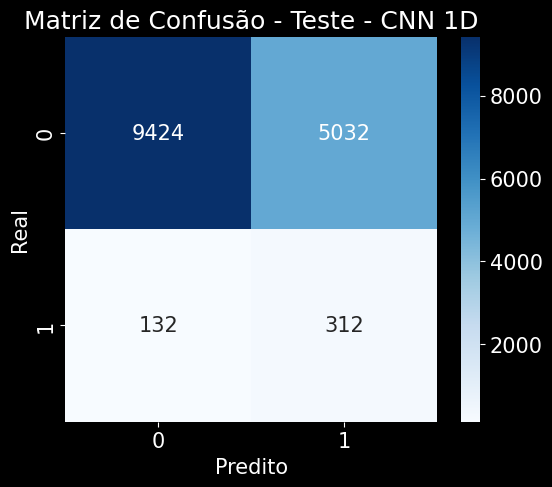

,dataset,threshold,accuracy,precision_classe_1,recall_classe_1,f1_classe_1,roc_auc,pr_auc
1,Teste - CNN 1D,0.5,0.653423,0.058383,0.702703,0.107809,0.737530,0.061130
0,Teste - LSTM,0.6,0.771342,0.055772,0.418919,0.098439,0.708308,0.053308


In [48]:
# ==========================================
# EVALUATION OF BOTH ARCHITECTURES ON THE TEST SET
# using the thresholds selected on the validation set
# ==========================================

lstm_test_result, y_score_test_lstm = evaluate_model(
    model=LSTM_Model,
    X=X_test,
    y=y_test,
    dataset_name="Teste - LSTM",
    threshold=BEST_THRESHOLD_LSTM,
    batch_size=BATCH_SIZE
)

cnn_test_result, y_score_test_cnn = evaluate_model(
    model=CNN1D_Model,
    X=X_test,
    y=y_test,
    dataset_name="Teste - CNN 1D",
    threshold=BEST_THRESHOLD_CNN,
    batch_size=BATCH_SIZE
)

test_comparison_df = pd.DataFrame([
    lstm_test_result,
    cnn_test_result
])

display(
    test_comparison_df[[
        "dataset",
        "threshold",
        "accuracy",
        "precision_classe_1",
        "recall_classe_1",
        "f1_classe_1",
        "roc_auc",
        "pr_auc"
    ]].sort_values(
        by=["f1_classe_1", "pr_auc", "roc_auc"],
        ascending=False
    )
)

In [49]:
# ==========================================
# FINAL PORTFOLIO SUMMARY
# ==========================================

portfolio_summary_df = pd.DataFrame([
    {
        "fase": "validação",
        "modelo": "LSTM",
        "threshold": BEST_THRESHOLD_LSTM,
        "precision_classe_1": lstm_val_result_best["precision_classe_1"],
        "recall_classe_1": lstm_val_result_best["recall_classe_1"],
        "f1_classe_1": lstm_val_result_best["f1_classe_1"],
        "roc_auc": lstm_val_result_best["roc_auc"],
        "pr_auc": lstm_val_result_best["pr_auc"]
    },
    {
        "fase": "validação",
        "modelo": "CNN 1D",
        "threshold": BEST_THRESHOLD_CNN,
        "precision_classe_1": cnn_val_result_best["precision_classe_1"],
        "recall_classe_1": cnn_val_result_best["recall_classe_1"],
        "f1_classe_1": cnn_val_result_best["f1_classe_1"],
        "roc_auc": cnn_val_result_best["roc_auc"],
        "pr_auc": cnn_val_result_best["pr_auc"]
    },
    {
        "fase": "teste",
        "modelo": "LSTM",
        "threshold": BEST_THRESHOLD_LSTM,
        "precision_classe_1": lstm_test_result["precision_classe_1"],
        "recall_classe_1": lstm_test_result["recall_classe_1"],
        "f1_classe_1": lstm_test_result["f1_classe_1"],
        "roc_auc": lstm_test_result["roc_auc"],
        "pr_auc": lstm_test_result["pr_auc"]
    },
    {
        "fase": "teste",
        "modelo": "CNN 1D",
        "threshold": BEST_THRESHOLD_CNN,
        "precision_classe_1": cnn_test_result["precision_classe_1"],
        "recall_classe_1": cnn_test_result["recall_classe_1"],
        "f1_classe_1": cnn_test_result["f1_classe_1"],
        "roc_auc": cnn_test_result["roc_auc"],
        "pr_auc": cnn_test_result["pr_auc"]
    }
])

display(portfolio_summary_df)

,fase,modelo,threshold,precision_classe_1,recall_classe_1,f1_classe_1,roc_auc,pr_auc
0,validação,LSTM,0.6,0.060034,0.471239,0.106500,0.726025,0.057329
1,validação,CNN 1D,0.5,0.062559,0.734513,0.115298,0.756338,0.066557
2,teste,LSTM,0.6,0.055772,0.418919,0.098439,0.708308,0.053308
3,teste,CNN 1D,0.5,0.058383,0.702703,0.107809,0.737530,0.061130


## 6. Partial Conclusion

Up to this point, the notebook has evolved from the original exercise into a more rigorous protocol, incorporating:

* temporal split;
* a gap between sets;
* normalization fitted only on the training set;
* validation separated from the test set;
* threshold calibration only on the validation set;
* a fairer comparison between the LSTM and the 1D CNN.

The final comparison showed that the 1D CNN was the best architecture in this project, consistently outperforming the LSTM on both the validation and test sets. Although both models still show low precision for the failure class, the 1D CNN maintained a better balance between sensitivity, F1, and class separation capability, making it the most solid baseline for continuing the work. As next steps, the project can evolve toward more applied scenarios, such as multi-step prediction, early warning, and temporal post-processing of alerts.



## 7. Extension: Multi-step Prediction and Early Warning

In this extra section, we will explore more applied formulations of the predictive maintenance problem. First, we will evaluate the model’s ability to predict failures over different time horizons, such as 1, 5, and 10 steps ahead. Next, we will investigate an early warning logic, in which the objective shifts from predicting the exact moment of failure to issuing a useful alert before it occurs. Finally, we will compare these formulations and test simple forms of temporal post-processing of alerts in order to reduce false positives.

###7.1 Multi-step with 1D CNN

At this stage, we will keep the same baseline architecture chosen earlier, the 1D CNN, but change the prediction horizon. Instead of predicting only the failure at the next instant, the model will be tested to predict failures at different temporal distances, such as 1, 5, and 10 steps ahead. The goal is to verify whether longer horizons make the problem more informative or simply less strict.

In [34]:
# ==========================================
# MULTI-STEP HORIZON CONFIGURATION
# ==========================================

MULTI_HORIZONS = [1, 5, 10]
MULTI_THRESHOLDS = np.arange(0.10, 0.91, 0.05)

print("Horizontes que serão testados:", MULTI_HORIZONS)


Horizontes que serão testados: [1, 5, 10]


In [35]:
# ==========================================
# FUNCTION TO SELECT A THRESHOLD ON THE VALIDATION SET
# ==========================================

def choose_best_threshold(y_true, y_score, thresholds=MULTI_THRESHOLDS):
    rows = []

    for th in thresholds:
        y_pred = (y_score >= th).astype(int)

        rows.append({
            "threshold": float(th),
            "precision_classe_1": precision_score(y_true, y_pred, zero_division=0),
            "recall_classe_1": recall_score(y_true, y_pred, zero_division=0),
            "f1_classe_1": f1_score(y_true, y_pred, zero_division=0)
        })

    threshold_df = pd.DataFrame(rows)
    best_idx = threshold_df["f1_classe_1"].idxmax()
    best_threshold = float(threshold_df.loc[best_idx, "threshold"])

    return best_threshold, threshold_df

In [36]:
# ==========================================
# COMPLETE FUNCTION TO TRAIN / RESUME /
# EVALUATE THE CNN AT A MULTI-STEP HORIZON
# ==========================================

def run_cnn_multistep_experiment(
    horizon,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    force_retrain=False,
    evaluate_only_if_exists=True
):
    print("\n" + "="*90)
    print(f"EXPERIMENTO MULTI-STEP | CNN 1D | HORIZON = {horizon}")
    print("="*90)

    # --------------------------------------------------
    # 1) Experiment name and persistent paths
    # --------------------------------------------------
    experiment_name = f"multistep_cnn_h{horizon}"
    paths = make_experiment_paths(experiment_name)

    print("\nDiretório do experimento:")
    print(paths["root"])

    # --------------------------------------------------
    # 2) Reconstruct the windows for this horizon
    # --------------------------------------------------
    X_train_h, y_train_h = build_windows(
        train_features, train_target,
        samples=BACK_LOG,
        horizon=horizon
    )
    X_val_h, y_val_h = build_windows(
        val_features, val_target,
        samples=BACK_LOG,
        horizon=horizon
    )
    X_test_h, y_test_h = build_windows(
        test_features, test_target,
        samples=BACK_LOG,
        horizon=horizon
    )

    print("\nShapes:")
    print("X_train:", X_train_h.shape, "| y_train:", y_train_h.shape)
    print("X_val  :", X_val_h.shape,   "| y_val  :", y_val_h.shape)
    print("X_test :", X_test_h.shape,  "| y_test :", y_test_h.shape)

    # --------------------------------------------------
    # 3) Positive-class prevalence
    # --------------------------------------------------
    train_pos_rate = float(y_train_h.mean())
    val_pos_rate = float(y_val_h.mean())
    test_pos_rate = float(y_test_h.mean())

    print("\nPrevalência da classe positiva:")
    print(f"Treino: {train_pos_rate:.4%}")
    print(f"Val   : {val_pos_rate:.4%}")
    print(f"Teste : {test_pos_rate:.4%}")

    # --------------------------------------------------
    # 4) Recalculate class weights for this horizon
    # --------------------------------------------------
    classes = np.unique(y_train_h.astype(int))
    class_weights_values = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train_h.astype(int)
    )
    class_weights_h = {
        int(cls): float(weight)
        for cls, weight in zip(classes, class_weights_values)
    }

    print("\nClass weights:")
    print(class_weights_h)

    # --------------------------------------------------
    # 5) Session cleanup and model creation
    # --------------------------------------------------
    tf.keras.backend.clear_session()

    model = build_cnn1d_model(
        input_shape=(X_train_h.shape[1], X_train_h.shape[2]),
        learning_rate=1e-4,
        filters=64,
        kernel_size=3,
        dropout_rate=0.2
    )

    callbacks_local = make_training_callbacks(paths, monitor="val_auc")

    # --------------------------------------------------
    # 6) Training / resumption policy
    # --------------------------------------------------
    history = None

    if force_retrain:
        print("\nforce_retrain=True -> removendo backup_state e history.csv antigos.")
        if paths["backup_dir"].exists():
            shutil.rmtree(paths["backup_dir"])
        if paths["history_csv"].exists():
            paths["history_csv"].unlink()

    best_model_exists = paths["best_model_path"].exists()

    if evaluate_only_if_exists and best_model_exists:
        print("\nModelo salvo encontrado. Pulando treino e carregando melhor modelo do Drive.")
        model = tf.keras.models.load_model(str(paths["best_model_path"]))
    else:
        if best_model_exists and not force_retrain:
            print("\nModelo salvo já existe. O treino poderá ser retomado do estado salvo, se houver backup.")
        else:
            print("\nNenhum modelo salvo anterior encontrado ou treino forçado solicitado. Iniciando treino.")

        history = model.fit(
            X_train_h,
            y_train_h,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(X_val_h, y_val_h),
            class_weight=class_weights_h,
            callbacks=callbacks_local,
            verbose=1
        )

        # also saves the last model from the session
        model.save(str(paths["last_model_path"]))
        print("\nÚltimo modelo da sessão salvo em:")
        print(paths["last_model_path"])

        # ensures that the primary reference is the best saved model at the end
        if paths["best_model_path"].exists():
            model = tf.keras.models.load_model(str(paths["best_model_path"]))
            print("\nMelhor modelo recarregado do Drive para avaliação final.")
        else:
            print("\nAviso: best_model.keras não foi encontrado; será usado o modelo atual em memória.")

    # --------------------------------------------------
    # 7) Training history
    # --------------------------------------------------
    history_df = None
    if paths["history_csv"].exists():
        history_df = pd.read_csv(paths["history_csv"])
        print("\nHistórico carregado de:")
        print(paths["history_csv"])
        display(history_df.tail())

    # --------------------------------------------------
    # 8) Evaluation on the validation set with threshold=0.5
    # --------------------------------------------------
    val_result_05, y_score_val = evaluate_model(
        model=model,
        X=X_val_h,
        y=y_val_h,
        dataset_name=f"Validação - CNN 1D | horizon={horizon}",
        threshold=0.5,
        batch_size=batch_size
    )

    # --------------------------------------------------
    # 9) Threshold selection on the validation set
    # --------------------------------------------------
    best_threshold, threshold_df = choose_best_threshold(
        y_true=y_val_h,
        y_score=y_score_val,
        thresholds=MULTI_THRESHOLDS
    )

    print("\nMelhor threshold na validação:", best_threshold)

    display(
        threshold_df.sort_values(
            by=["f1_classe_1", "recall_classe_1", "precision_classe_1"],
            ascending=False
        ).head(10)
    )

    save_dataframe(threshold_df, paths["threshold_csv"])

    # --------------------------------------------------
    # 10) Reevaluation of the validation set with the best threshold
    # --------------------------------------------------
    val_result_best, _ = evaluate_model(
        model=model,
        X=X_val_h,
        y=y_val_h,
        dataset_name=f"Validação - CNN 1D (melhor threshold) | horizon={horizon}",
        threshold=best_threshold,
        batch_size=batch_size
    )

    # --------------------------------------------------
    # 11) Final evaluation on the test set
    # --------------------------------------------------
    test_result, y_score_test = evaluate_model(
        model=model,
        X=X_test_h,
        y=y_test_h,
        dataset_name=f"Teste - CNN 1D | horizon={horizon}",
        threshold=best_threshold,
        batch_size=batch_size
    )

    # --------------------------------------------------
    # 12) Consolidated summary
    # --------------------------------------------------
    summary = {
        "experiment_name": experiment_name,
        "horizon": horizon,
        "threshold_escolhido": best_threshold,
        "train_pos_rate": train_pos_rate,
        "val_pos_rate": val_pos_rate,
        "test_pos_rate": test_pos_rate,

        "val_precision_classe_1": val_result_best["precision_classe_1"],
        "val_recall_classe_1": val_result_best["recall_classe_1"],
        "val_f1_classe_1": val_result_best["f1_classe_1"],
        "val_roc_auc": val_result_best["roc_auc"],
        "val_pr_auc": val_result_best["pr_auc"],

        "test_precision_classe_1": test_result["precision_classe_1"],
        "test_recall_classe_1": test_result["recall_classe_1"],
        "test_f1_classe_1": test_result["f1_classe_1"],
        "test_roc_auc": test_result["roc_auc"],
        "test_pr_auc": test_result["pr_auc"]
    }

    summary_df = pd.DataFrame([summary])
    save_dataframe(summary_df, paths["summary_csv"])
    save_json_dict(paths["metrics_json"], summary)

    print("\nResumo salvo em:")
    print(paths["summary_csv"])
    print(paths["metrics_json"])

    # --------------------------------------------------
    # 13) Experiment return value
    # --------------------------------------------------
    return {
        "experiment_name": experiment_name,
        "paths": paths,
        "model": model,
        "history": history,
        "history_df": history_df,
        "threshold_df": threshold_df,
        "best_threshold": best_threshold,
        "val_result_05": val_result_05,
        "val_result_best": val_result_best,
        "test_result": test_result,
        "summary": summary,
        "summary_df": summary_df,
        "y_score_test": y_score_test,
        "X_test_h": X_test_h,
        "y_test_h": y_test_h,
        "class_weights_h": class_weights_h
    }

In [37]:
# ==========================================
# HELPERS FOR SAVING TABLES
# ==========================================

def save_dataframe(df, path):
    df.to_csv(path, index=False)
    print("Arquivo salvo em:", path)


EXPERIMENTO MULTI-STEP | CNN 1D | HORIZON = 1

Diretório do experimento:
/content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/multistep_cnn_h1

Shapes:
X_train: (69950, 50, 2) | y_train: (69950,)
X_val  : (14900, 50, 2) | y_val  : (14900,)
X_test : (14900, 50, 2) | y_test : (14900,)

Prevalência da classe positiva:
Treino: 2.9392%
Val   : 3.0336%
Teste : 2.9799%

Class weights:
{0: 0.5151412495949569, 1: 17.011186770428015}

Modelo salvo encontrado. Pulando treino e carregando melhor modelo do Drive.

Histórico carregado de:
/content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/multistep_cnn_h1/history.csv


,epoch,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
25,25,0.627734,0.734924,0.616847,0.056476,0.742704,0.649195,0.753426,0.610816,0.060879,0.732301
26,26,0.631036,0.735554,0.615051,0.056433,0.734922,0.642550,0.753308,0.614913,0.062163,0.765487
27,27,0.628578,0.736068,0.615926,0.056501,0.741245,0.642013,0.753522,0.615303,0.062074,0.765487
28,28,0.627806,0.736381,0.613876,0.056749,0.746595,0.643490,0.753529,0.613228,0.061846,0.758850
29,29,0.629650,0.737292,0.613134,0.056856,0.744163,0.640940,0.753757,0.615278,0.062053,0.767699



AVALIAÇÃO - Validação - CNN 1D | horizon=1 | threshold=0.5

Métricas principais:
loss                  0.615278
accuracy              0.640940
precision_classe_1    0.062053
recall_classe_1       0.767699
f1_classe_1           0.114825
roc_auc               0.753548
pr_auc                0.066313
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.9887    0.6370    0.7748     14448
           1     0.0621    0.7677    0.1148       452

    accuracy                         0.6409     14900
   macro avg     0.5254    0.7023    0.4448     14900
weighted avg     0.9606    0.6409    0.7548     14900



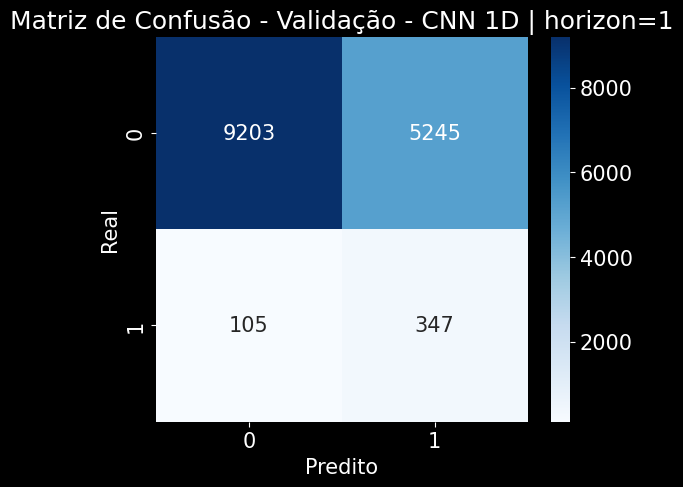


Melhor threshold na validação: 0.5000000000000001


,threshold,precision_classe_1,recall_classe_1,f1_classe_1
8,0.50,0.062053,0.767699,0.114825
9,0.55,0.063319,0.502212,0.112460
10,0.60,0.066633,0.294248,0.108660
7,0.45,0.056181,0.915929,0.105869
11,0.65,0.076433,0.159292,0.103300
6,0.40,0.048008,0.962389,0.091454
5,0.35,0.040690,0.986726,0.078156
4,0.30,0.036105,0.993363,0.069677
12,0.70,0.067797,0.070796,0.069264
3,0.25,0.033811,0.997788,0.065405


Arquivo salvo em: /content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/multistep_cnn_h1/thresholds.csv

AVALIAÇÃO - Validação - CNN 1D (melhor threshold) | horizon=1 | threshold=0.5000000000000001

Métricas principais:
loss                  0.615278
accuracy              0.640940
precision_classe_1    0.062053
recall_classe_1       0.767699
f1_classe_1           0.114825
roc_auc               0.753548
pr_auc                0.066313
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.9887    0.6370    0.7748     14448
           1     0.0621    0.7677    0.1148       452

    accuracy                         0.6409     14900
   macro avg     0.5254    0.7023    0.4448     14900
weighted avg     0.9606    0.6409    0.7548     14900



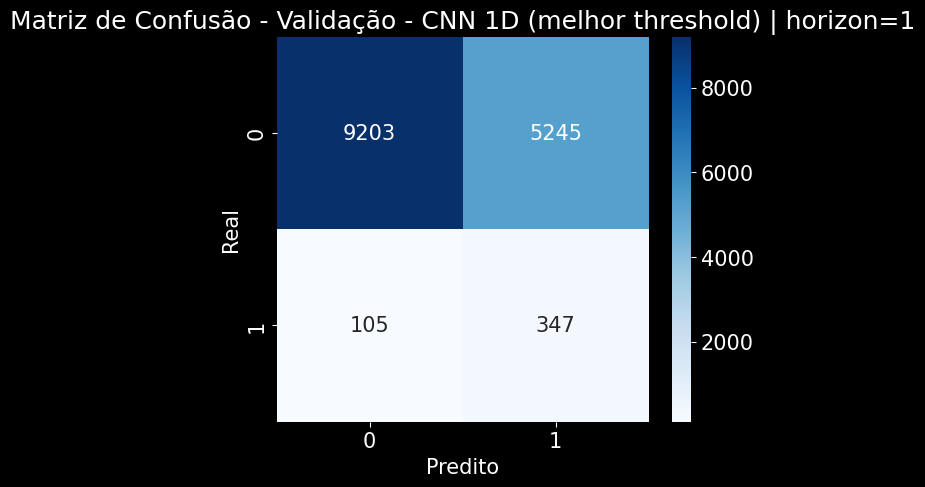


AVALIAÇÃO - Teste - CNN 1D | horizon=1 | threshold=0.5000000000000001

Métricas principais:
loss                  0.616280
accuracy              0.636309
precision_classe_1    0.057306
recall_classe_1       0.725225
f1_classe_1           0.106218
roc_auc               0.737160
pr_auc                0.061051
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.9869    0.6336    0.7717     14456
           1     0.0573    0.7252    0.1062       444

    accuracy                         0.6363     14900
   macro avg     0.5221    0.6794    0.4390     14900
weighted avg     0.9592    0.6363    0.7519     14900



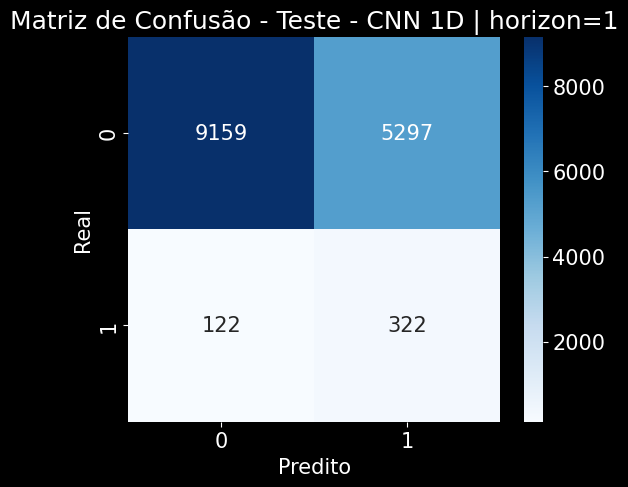

Arquivo salvo em: /content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/multistep_cnn_h1/summary.csv

Resumo salvo em:
/content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/multistep_cnn_h1/summary.csv
/content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/multistep_cnn_h1/metrics.json

EXPERIMENTO MULTI-STEP | CNN 1D | HORIZON = 5

Diretório do experimento:
/content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/multistep_cnn_h5

Shapes:
X_train: (69946, 50, 2) | y_train: (69946,)
X_val  : (14896, 50, 2) | y_val  : (14896,)
X_test : (14896, 50, 2) | y_test : (14896,)

Prevalência da classe positiva:
Treino: 2.9394%
Val   : 3.0344%
Teste : 2.9807%

Class weights:
{0: 0.5151421416998085, 1: 17.0102140077821}

Modelo salvo encontrado. Pulando treino e carregando melhor modelo do Drive.

Histórico carregado de:
/content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/multistep_cnn_h5/history.csv


,epoch,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
25,25,0.575587,0.681128,0.653629,0.047583,0.706712,0.504498,0.696014,0.681193,0.050357,0.858407
26,26,0.569239,0.678671,0.653511,0.046960,0.707685,0.506512,0.696659,0.681097,0.050437,0.856195
27,27,0.571341,0.680088,0.652106,0.047946,0.720331,0.513695,0.696564,0.677638,0.050437,0.842920
28,28,0.572284,0.679581,0.651055,0.047255,0.707198,0.509801,0.697054,0.679335,0.050643,0.853982
29,29,0.573414,0.685562,0.648106,0.047966,0.716926,0.513494,0.697027,0.678149,0.050655,0.847345



AVALIAÇÃO - Validação - CNN 1D | horizon=5 | threshold=0.5

Métricas principais:
loss                  0.679335
accuracy              0.509801
precision_classe_1    0.050643
recall_classe_1       0.853982
f1_classe_1           0.095616
roc_auc               0.696797
pr_auc                0.051238
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.9909    0.4990    0.6638     14444
           1     0.0506    0.8540    0.0956       452

    accuracy                         0.5098     14896
   macro avg     0.5208    0.6765    0.3797     14896
weighted avg     0.9624    0.5098    0.6465     14896



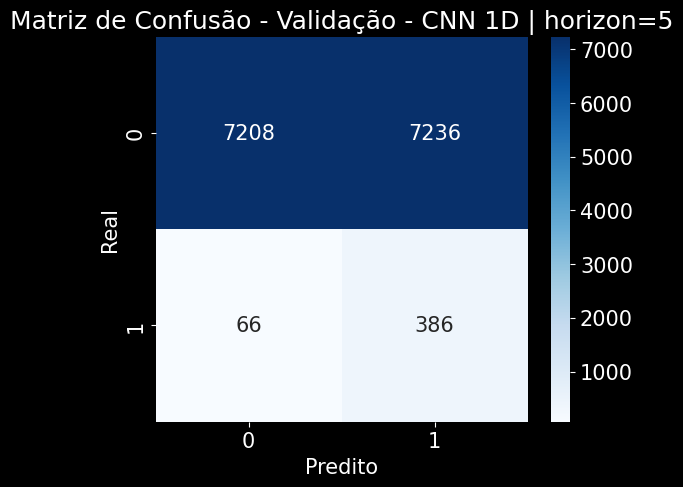


Melhor threshold na validação: 0.5500000000000002


,threshold,precision_classe_1,recall_classe_1,f1_classe_1
9,0.55,0.055961,0.457965,0.099735
8,0.50,0.050643,0.853982,0.095616
10,0.60,0.055105,0.150442,0.080664
7,0.45,0.042111,0.951327,0.080653
6,0.40,0.035570,0.973451,0.068632
5,0.35,0.032900,0.984513,0.063671
4,0.30,0.032139,1.000000,0.062276
3,0.25,0.031404,1.000000,0.060896
2,0.20,0.030978,1.000000,0.060094
1,0.15,0.030725,1.000000,0.059619


Arquivo salvo em: /content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/multistep_cnn_h5/thresholds.csv

AVALIAÇÃO - Validação - CNN 1D (melhor threshold) | horizon=5 | threshold=0.5500000000000002

Métricas principais:
loss                  0.679335
accuracy              0.749127
precision_classe_1    0.055961
recall_classe_1       0.457965
f1_classe_1           0.099735
roc_auc               0.696797
pr_auc                0.051238
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.9781    0.7582    0.8543     14444
           1     0.0560    0.4580    0.0997       452

    accuracy                         0.7491     14896
   macro avg     0.5170    0.6081    0.4770     14896
weighted avg     0.9501    0.7491    0.8314     14896



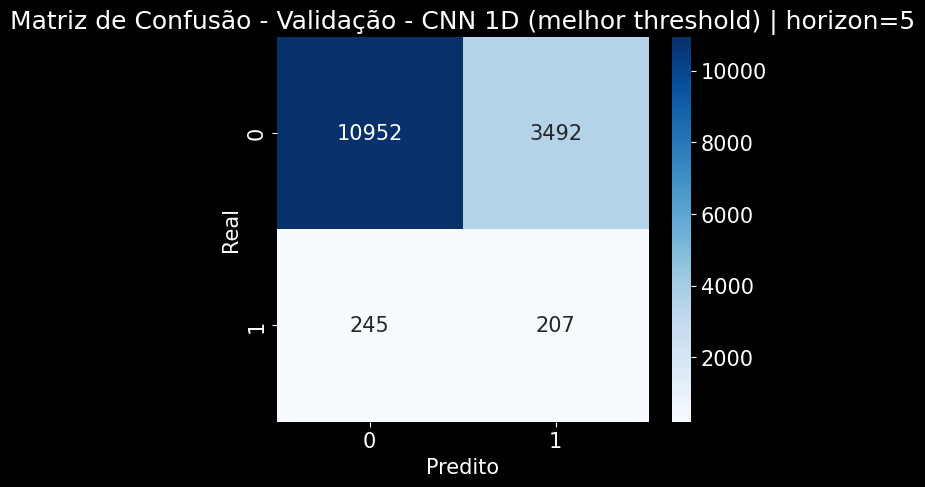


AVALIAÇÃO - Teste - CNN 1D | horizon=5 | threshold=0.5500000000000002

Métricas principais:
loss                  0.677411
accuracy              0.747650
precision_classe_1    0.047502
recall_classe_1       0.391892
f1_classe_1           0.084733
roc_auc               0.675133
pr_auc                0.046815
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.9760    0.7586    0.8536     14452
           1     0.0475    0.3919    0.0847       444

    accuracy                         0.7477     14896
   macro avg     0.5117    0.5752    0.4692     14896
weighted avg     0.9483    0.7477    0.8307     14896



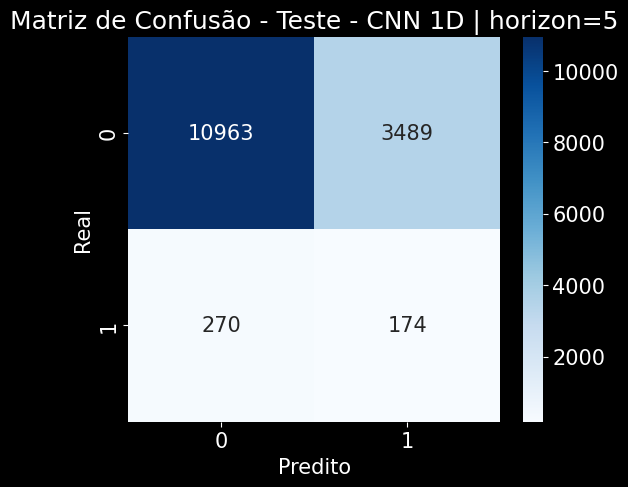

Arquivo salvo em: /content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/multistep_cnn_h5/summary.csv

Resumo salvo em:
/content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/multistep_cnn_h5/summary.csv
/content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/multistep_cnn_h5/metrics.json

EXPERIMENTO MULTI-STEP | CNN 1D | HORIZON = 10

Diretório do experimento:
/content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/multistep_cnn_h10

Shapes:
X_train: (69941, 50, 2) | y_train: (69941,)
X_val  : (14891, 50, 2) | y_val  : (14891,)
X_test : (14891, 50, 2) | y_test : (14891,)

Prevalência da classe positiva:
Treino: 2.9396%
Val   : 3.0354%
Teste : 2.9817%

Class weights:
{0: 0.515143256978714, 1: 17.00899805447471}

Modelo salvo encontrado. Pulando treino e carregando melhor modelo do Drive.

Histórico carregado de:
/content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/multistep_cnn_h10/history.csv


,epoch,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
25,25,0.594315,0.639212,0.675395,0.043851,0.615272,0.488349,0.663459,0.696792,0.043445,0.754425
26,26,0.599491,0.641859,0.673942,0.044536,0.617218,0.487274,0.664276,0.697078,0.043705,0.761062
27,27,0.595016,0.641463,0.673713,0.044305,0.621109,0.487006,0.663827,0.697047,0.043798,0.763274
28,28,0.595302,0.643227,0.672769,0.044904,0.629864,0.494796,0.664225,0.695226,0.043865,0.752212
29,29,0.598261,0.645573,0.672244,0.044911,0.625000,0.490565,0.663650,0.696585,0.043862,0.758850



AVALIAÇÃO - Validação - CNN 1D | horizon=10 | threshold=0.5

Métricas principais:
loss                  0.697078
accuracy              0.487274
precision_classe_1    0.043705
recall_classe_1       0.761062
f1_classe_1           0.082663
roc_auc               0.664382
pr_auc                0.053513
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.9846    0.4787    0.6442     14439
           1     0.0437    0.7611    0.0827       452

    accuracy                         0.4873     14891
   macro avg     0.5142    0.6199    0.3634     14891
weighted avg     0.9561    0.4873    0.6272     14891



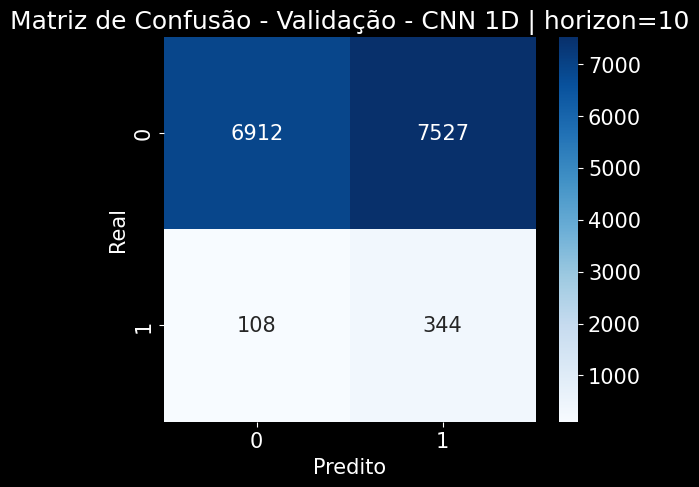


Melhor threshold na validação: 0.5500000000000002


,threshold,precision_classe_1,recall_classe_1,f1_classe_1
9,0.55,0.060590,0.245575,0.097198
8,0.50,0.043705,0.761062,0.082663
10,0.60,0.074380,0.079646,0.076923
7,0.45,0.033231,0.960177,0.064239
6,0.40,0.031322,0.986726,0.060717
5,0.35,0.030798,0.993363,0.059743
3,0.25,0.030574,1.000000,0.059333
4,0.30,0.030569,0.995575,0.059316
2,0.20,0.030495,1.000000,0.059186
1,0.15,0.030432,1.000000,0.059066


Arquivo salvo em: /content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/multistep_cnn_h10/thresholds.csv

AVALIAÇÃO - Validação - CNN 1D (melhor threshold) | horizon=10 | threshold=0.5500000000000002

Métricas principais:
loss                  0.697078
accuracy              0.861527
precision_classe_1    0.060590
recall_classe_1       0.245575
f1_classe_1           0.097198
roc_auc               0.664382
pr_auc                0.053513
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.9739    0.8808    0.9250     14439
           1     0.0606    0.2456    0.0972       452

    accuracy                         0.8615     14891
   macro avg     0.5172    0.5632    0.5111     14891
weighted avg     0.9462    0.8615    0.8999     14891



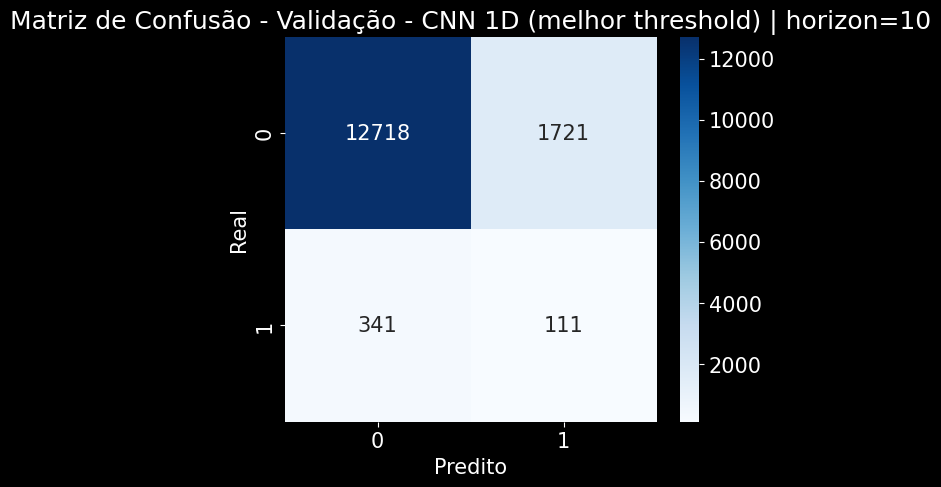


AVALIAÇÃO - Teste - CNN 1D | horizon=10 | threshold=0.5500000000000002

Métricas principais:
loss                  0.697991
accuracy              0.855886
precision_classe_1    0.051633
recall_classe_1       0.220721
f1_classe_1           0.083689
roc_auc               0.630185
pr_auc                0.045081
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.9734    0.8754    0.9218     14447
           1     0.0516    0.2207    0.0837       444

    accuracy                         0.8559     14891
   macro avg     0.5125    0.5481    0.5027     14891
weighted avg     0.9459    0.8559    0.8968     14891



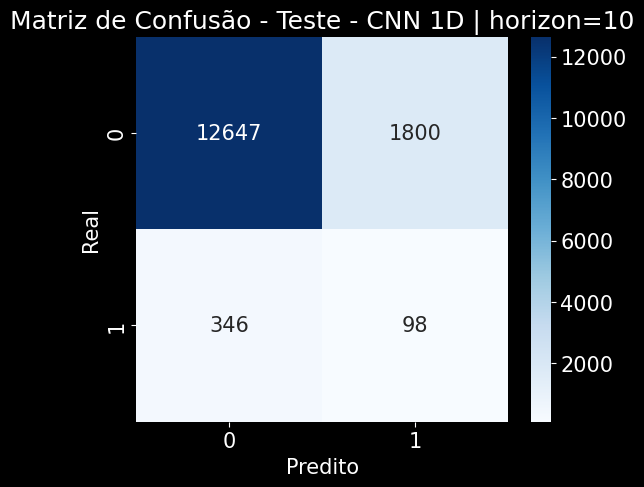

Arquivo salvo em: /content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/multistep_cnn_h10/summary.csv

Resumo salvo em:
/content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/multistep_cnn_h10/summary.csv
/content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/multistep_cnn_h10/metrics.json


In [52]:
# ==========================================
# RUN MULTI-STEP EXPERIMENTS
# ==========================================

multistep_results = {}

for horizon in MULTI_HORIZONS:
    multistep_results[horizon] = run_cnn_multistep_experiment(horizon=horizon)

In [53]:
# ==========================================
# FINAL TABLE - MULTI-STEP 1D CNN
# ==========================================

multistep_summary_df = pd.DataFrame(
    [multistep_results[h]["summary"] for h in MULTI_HORIZONS]
)

display(
    multistep_summary_df.sort_values(
        by=["test_f1_classe_1", "test_pr_auc", "test_roc_auc"],
        ascending=False
    )
)

,experiment_name,horizon,threshold_escolhido,train_pos_rate,val_pos_rate,test_pos_rate,val_precision_classe_1,val_recall_classe_1,val_f1_classe_1,val_roc_auc,val_pr_auc,test_precision_classe_1,test_recall_classe_1,test_f1_classe_1,test_roc_auc,test_pr_auc
0,multistep_cnn_h1,1,0.50,0.029392,0.030336,0.029799,0.062053,0.767699,0.114825,0.753548,0.066313,0.057306,0.725225,0.106218,0.737160,0.061051
1,multistep_cnn_h5,5,0.55,0.029394,0.030344,0.029807,0.055961,0.457965,0.099735,0.696797,0.051238,0.047502,0.391892,0.084733,0.675133,0.046815
2,multistep_cnn_h10,10,0.55,0.029396,0.030354,0.029817,0.060590,0.245575,0.097198,0.664382,0.053513,0.051633,0.220721,0.083689,0.630185,0.045081


**Interpretation of This Stage**


In this experiment, increasing the prediction horizon did not substantially change the prevalence of the positive class, since the target was defined as the occurrence of failure at an exact future step rather than within a future interval. Under this formulation, the results showed a progressive degradation in performance as the horizon increased, with lower F1, ROC-AUC, and PR-AUC for longer horizons. This suggests that predicting the exact occurrence of failure becomes more difficult as the forecast moves farther into the future. Therefore, the main takeaway of this stage is not that longer horizons make the task easier, but that exact-step forecasting loses discriminative power as temporal distance increases.

## 7.2 Early Warning with 1D CNN

In the previous stage, the model was evaluated under an exact-step forecasting setup, that is, predicting whether a failure would occur at a specific future step such as 1, 5, or 10 steps ahead. In this section, the problem formulation becomes more operational: instead of predicting the exact timing of failure, the model will be trained to issue an alert whenever at least one failure is expected to occur within a future warning window.

This change makes the task more aligned with practical predictive maintenance scenarios, in which anticipating an upcoming failure is often more useful than estimating its exact timestamp. The same 1D CNN architecture will be retained so that the comparison focuses on the formulation of the target rather than on architectural changes.


### Early Warning Labeling Logic

For each input window of past observations, the target will now be defined as follows:

- target = 1 if at least one failure occurs within the next `k` time steps;
- target = 0 otherwise.

Thus, unlike the multi-step formulation, which asks whether failure happens at an exact future step, the early warning formulation asks whether failure is expected to happen at any point inside a future interval. This makes the problem less strict and potentially more useful from an operational perspective.

Because the target now aggregates future events over an interval, the prevalence of the positive class is expected to increase as the warning window becomes larger. Therefore, this section will evaluate not only predictive performance, but also how the new formulation changes class balance and the practical meaning of the alerts.

### Building Windows for Early Warning

The temporal windows remain the same on the input side: each sample contains the previous `BACK_LOG` observations of temperature and vibration. What changes is the target construction.

Instead of selecting only one exact future point, the code now inspects a future block of length `warning_window`. If at least one failure appears inside that block, the current sample receives label 1. This transforms the task into a binary alert prediction problem.

In [38]:
def build_early_warning_windows(features_array, target_array, samples, warning_window=5):
    X, y = [], []

    max_start = len(features_array) - samples - warning_window + 1

    for i in range(max_start):
        x_window = features_array[i : i + samples]

        future_block = target_array[i + samples : i + samples + warning_window]

        y_target = 1.0 if np.max(future_block) > 0 else 0.0

        X.append(x_window)
        y.append(y_target)

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)

    return X, y

In [39]:
EARLY_WARNING_WINDOWS = [5, 10]

### Experimental Pipeline for Early Warning

The experimental protocol will remain consistent with the previous sections:

- temporal split with gap between sets;
- normalization fitted only on the training set;
- class weights computed only on the training data;
- threshold selection performed only on the validation set;
- final evaluation reserved for the test set.

This consistency is important because it allows the comparison between exact-step forecasting and early warning to reflect a genuine change in problem formulation rather than a change in experimental rigor.

In [41]:
def run_cnn_early_warning_experiment(
    warning_window,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    force_retrain=False,
    evaluate_only_if_exists=True
):
    print("\n" + "="*90)
    print(f"EXPERIMENTO EARLY WARNING | CNN 1D | WINDOW = {warning_window}")
    print("="*90)

    experiment_name = f"earlywarning_cnn_w{warning_window}"
    paths = make_experiment_paths(experiment_name)

    X_train_w, y_train_w = build_early_warning_windows(
        train_features, train_target,
        samples=BACK_LOG,
        warning_window=warning_window
    )
    X_val_w, y_val_w = build_early_warning_windows(
        val_features, val_target,
        samples=BACK_LOG,
        warning_window=warning_window
    )
    X_test_w, y_test_w = build_early_warning_windows(
        test_features, test_target,
        samples=BACK_LOG,
        warning_window=warning_window
    )

    print("\nShapes:")
    print("X_train:", X_train_w.shape, "| y_train:", y_train_w.shape)
    print("X_val  :", X_val_w.shape,   "| y_val  :", y_val_w.shape)
    print("X_test :", X_test_w.shape,  "| y_test :", y_test_w.shape)

    train_pos_rate = float(y_train_w.mean())
    val_pos_rate = float(y_val_w.mean())
    test_pos_rate = float(y_test_w.mean())

    print("\nPrevalência da classe positiva:")
    print(f"Treino: {train_pos_rate:.4%}")
    print(f"Val   : {val_pos_rate:.4%}")
    print(f"Teste : {test_pos_rate:.4%}")

    classes = np.unique(y_train_w.astype(int))
    class_weights_values = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train_w.astype(int)
    )
    class_weights_w = {
        int(cls): float(weight)
        for cls, weight in zip(classes, class_weights_values)
    }

    print("\nClass weights:")
    print(class_weights_w)

    tf.keras.backend.clear_session()

    model = build_cnn1d_model(
        input_shape=(X_train_w.shape[1], X_train_w.shape[2]),
        learning_rate=1e-4,
        filters=64,
        kernel_size=3,
        dropout_rate=0.2
    )

    callbacks_local = make_training_callbacks(paths, monitor="val_auc")
    history = None

    if force_retrain:
        print("\nforce_retrain=True -> removendo backup_state e history.csv antigos.")
        if paths["backup_dir"].exists():
            shutil.rmtree(paths["backup_dir"])
        if paths["history_csv"].exists():
            paths["history_csv"].unlink()

    best_model_exists = paths["best_model_path"].exists()

    if evaluate_only_if_exists and best_model_exists:
        print("\nModelo salvo encontrado. Pulando treino e carregando melhor modelo do Drive.")
        model = tf.keras.models.load_model(str(paths["best_model_path"]))
    else:
        history = model.fit(
            X_train_w,
            y_train_w,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(X_val_w, y_val_w),
            class_weight=class_weights_w,
            callbacks=callbacks_local,
            verbose=1
        )

        model.save(str(paths["last_model_path"]))

        if paths["best_model_path"].exists():
            model = tf.keras.models.load_model(str(paths["best_model_path"]))

    history_df = None
    if paths["history_csv"].exists():
        history_df = pd.read_csv(paths["history_csv"])
        display(history_df.tail())

    val_result_05, y_score_val = evaluate_model(
        model=model,
        X=X_val_w,
        y=y_val_w,
        dataset_name=f"Validação - Early Warning | window={warning_window}",
        threshold=0.5,
        batch_size=batch_size
    )

    best_threshold, threshold_df = choose_best_threshold(
        y_true=y_val_w,
        y_score=y_score_val,
        thresholds=MULTI_THRESHOLDS
    )

    print("\nMelhor threshold na validação:", best_threshold)

    display(
        threshold_df.sort_values(
            by=["f1_classe_1", "recall_classe_1", "precision_classe_1"],
            ascending=False
        ).head(10)
    )

    save_dataframe(threshold_df, paths["threshold_csv"])

    val_result_best, _ = evaluate_model(
        model=model,
        X=X_val_w,
        y=y_val_w,
        dataset_name=f"Validação - Early Warning (melhor threshold) | window={warning_window}",
        threshold=best_threshold,
        batch_size=batch_size
    )

    test_result, y_score_test = evaluate_model(
        model=model,
        X=X_test_w,
        y=y_test_w,
        dataset_name=f"Teste - Early Warning | window={warning_window}",
        threshold=best_threshold,
        batch_size=batch_size
    )

    summary = {
        "experiment_name": experiment_name,
        "warning_window": warning_window,
        "threshold_escolhido": best_threshold,
        "train_pos_rate": train_pos_rate,
        "val_pos_rate": val_pos_rate,
        "test_pos_rate": test_pos_rate,

        "val_precision_classe_1": val_result_best["precision_classe_1"],
        "val_recall_classe_1": val_result_best["recall_classe_1"],
        "val_f1_classe_1": val_result_best["f1_classe_1"],
        "val_roc_auc": val_result_best["roc_auc"],
        "val_pr_auc": val_result_best["pr_auc"],

        "test_precision_classe_1": test_result["precision_classe_1"],
        "test_recall_classe_1": test_result["recall_classe_1"],
        "test_f1_classe_1": test_result["f1_classe_1"],
        "test_roc_auc": test_result["roc_auc"],
        "test_pr_auc": test_result["pr_auc"]
    }

    summary_df = pd.DataFrame([summary])
    save_dataframe(summary_df, paths["summary_csv"])
    save_json_dict(paths["metrics_json"], summary)

    return {
        "experiment_name": experiment_name,
        "paths": paths,
        "model": model,
        "history": history,
        "history_df": history_df,
        "threshold_df": threshold_df,
        "best_threshold": best_threshold,
        "val_result_05": val_result_05,
        "val_result_best": val_result_best,
        "test_result": test_result,
        "summary": summary,
        "summary_df": summary_df,
        "y_score_test": y_score_test,
        "X_test_w": X_test_w,
        "y_test_w": y_test_w,
        "class_weights_w": class_weights_w
    }

### Running Early Warning Experiments

The model will be tested with different warning windows, such as 5 and 10 future steps. This allows us to evaluate whether broader alert intervals improve the practical usefulness of the system or simply produce more positives and more false alarms.

At this stage, the objective is not yet to optimize the alert stream itself, but to understand how the reformulated target affects discrimination, recall, precision, and PR-AUC.


EXPERIMENTO EARLY WARNING | CNN 1D | WINDOW = 5

Shapes:
X_train: (69946, 50, 2) | y_train: (69946,)
X_val  : (14896, 50, 2) | y_val  : (14896,)
X_test : (14896, 50, 2) | y_test : (14896,)

Prevalência da classe positiva:
Treino: 14.6971%
Val   : 15.1719%
Teste : 14.8899%

Class weights:
{0: 0.5861462139241779, 1: 3.40204280155642}


,epoch,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
25,25,0.636462,0.737239,0.596733,0.253707,0.758949,0.657425,0.749161,0.586755,0.272451,0.753097
26,26,0.637292,0.737381,0.595264,0.254873,0.763132,0.656149,0.749221,0.587124,0.272279,0.757080
27,27,0.636577,0.738954,0.593999,0.254093,0.760895,0.657962,0.749449,0.584692,0.273091,0.754867
28,28,0.638078,0.738722,0.593366,0.254755,0.759630,0.657358,0.749481,0.585235,0.273133,0.757522
29,29,0.637749,0.739787,0.591953,0.254724,0.760603,0.657962,0.749712,0.584474,0.273236,0.755752



AVALIAÇÃO - Validação - Early Warning | window=5 | threshold=0.5

Métricas principais:
loss                  0.584474
accuracy              0.657962
precision_classe_1    0.273236
recall_classe_1       0.755752
f1_classe_1           0.401363
roc_auc               0.749741
pr_auc                0.279122
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.9361    0.6405    0.7606     12636
           1     0.2732    0.7558    0.4014      2260

    accuracy                         0.6580     14896
   macro avg     0.6047    0.6981    0.5810     14896
weighted avg     0.8356    0.6580    0.7061     14896



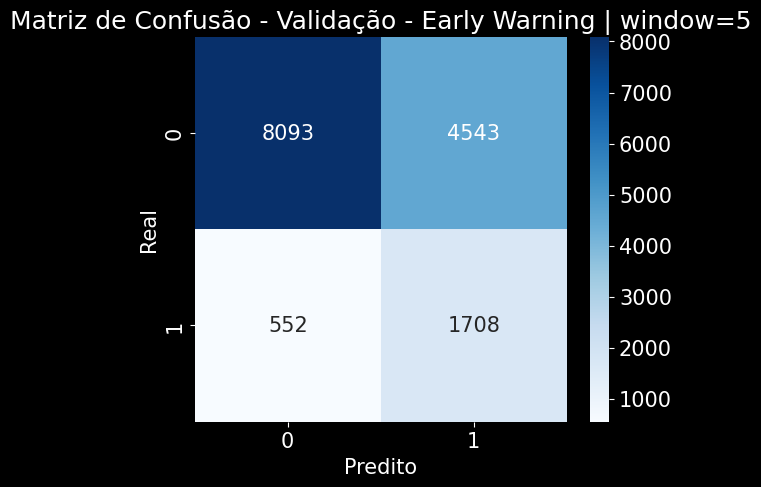


Melhor threshold na validação: 0.45000000000000007


,threshold,precision_classe_1,recall_classe_1,f1_classe_1
7,0.45,0.263753,0.846460,0.402186
8,0.50,0.273236,0.755752,0.401363
6,0.40,0.250000,0.899558,0.391263
9,0.55,0.277561,0.630531,0.385448
5,0.35,0.235596,0.933628,0.376248
10,0.60,0.283879,0.479204,0.356543
4,0.30,0.218502,0.961504,0.356084
3,0.25,0.199026,0.976549,0.330661
11,0.65,0.293478,0.322566,0.307336
2,0.20,0.181450,0.991150,0.306744


Arquivo salvo em: /content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/earlywarning_cnn_w5/thresholds.csv

AVALIAÇÃO - Validação - Early Warning (melhor threshold) | window=5 | threshold=0.45000000000000007

Métricas principais:
loss                  0.584474
accuracy              0.618220
precision_classe_1    0.263753
recall_classe_1       0.846460
f1_classe_1           0.402186
roc_auc               0.749741
pr_auc                0.279122
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.9546    0.5774    0.7196     12636
           1     0.2638    0.8465    0.4022      2260

    accuracy                         0.6182     14896
   macro avg     0.6092    0.7119    0.5609     14896
weighted avg     0.8498    0.6182    0.6714     14896



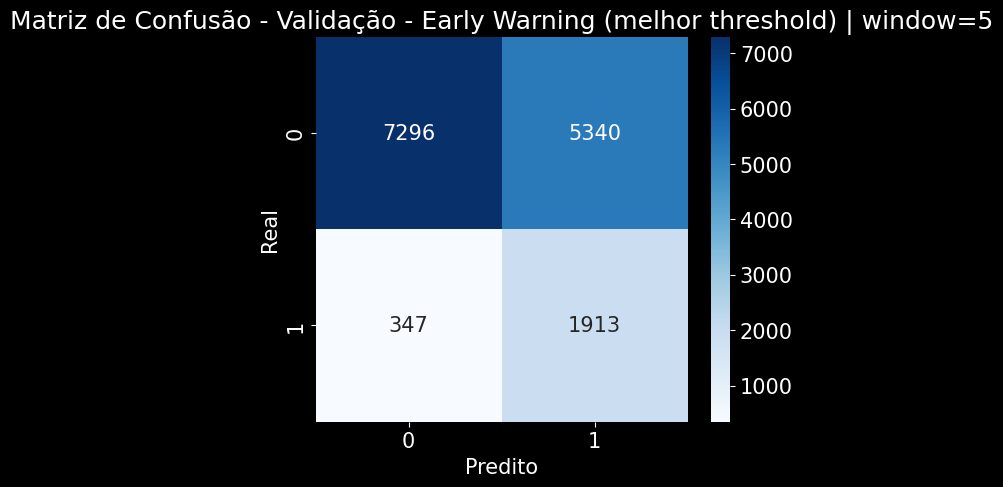


AVALIAÇÃO - Teste - Early Warning | window=5 | threshold=0.45000000000000007

Métricas principais:
loss                  0.588626
accuracy              0.604995
precision_classe_1    0.248422
recall_classe_1       0.816050
f1_classe_1           0.380892
roc_auc               0.740148
pr_auc                0.269729
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.9464    0.5681    0.7100     12678
           1     0.2484    0.8161    0.3809      2218

    accuracy                         0.6050     14896
   macro avg     0.5974    0.6921    0.5454     14896
weighted avg     0.8425    0.6050    0.6610     14896



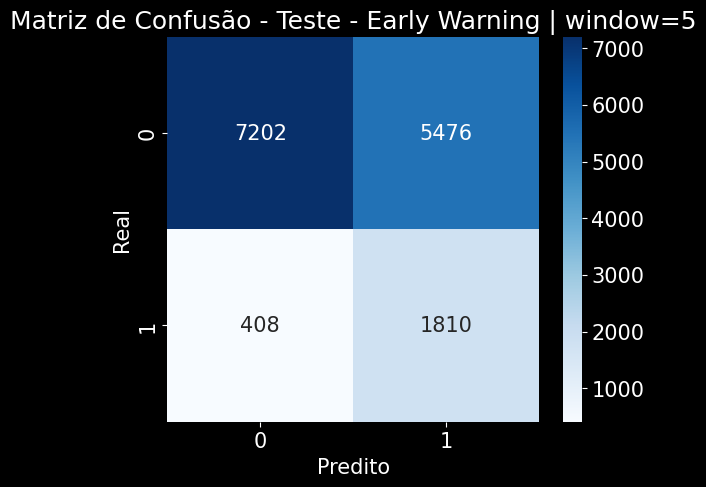

Arquivo salvo em: /content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/earlywarning_cnn_w5/summary.csv

EXPERIMENTO EARLY WARNING | CNN 1D | WINDOW = 10

Shapes:
X_train: (69941, 50, 2) | y_train: (69941,)
X_val  : (14891, 50, 2) | y_val  : (14891,)
X_test : (14891, 50, 2) | y_test : (14891,)

Prevalência da classe positiva:
Treino: 29.3905%
Val   : 30.3270%
Teste : 29.7697%

Class weights:
{0: 0.7081198744558064, 1: 1.7012307841992607}


,epoch,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
25,25,0.642227,0.716642,0.616551,0.435371,0.731952,0.653616,0.730411,0.612680,0.456727,0.750221
26,26,0.644386,0.718220,0.614648,0.437507,0.734968,0.653482,0.730457,0.611961,0.456720,0.752436
27,27,0.644286,0.718515,0.614140,0.437505,0.736135,0.653079,0.730926,0.611218,0.456294,0.751329
28,28,0.644143,0.719296,0.612606,0.437135,0.732876,0.653818,0.731328,0.609893,0.456865,0.749336
29,29,0.644972,0.719527,0.612145,0.438124,0.736281,0.652542,0.731644,0.610021,0.455803,0.751329



AVALIAÇÃO - Validação - Early Warning | window=10 | threshold=0.5

Métricas principais:
loss                  0.610021
accuracy              0.652542
precision_classe_1    0.455803
recall_classe_1       0.751329
f1_classe_1           0.567391
roc_auc               0.731660
pr_auc                0.473128
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.8492    0.6095    0.7097     10375
           1     0.4558    0.7513    0.5674      4516

    accuracy                         0.6525     14891
   macro avg     0.6525    0.6804    0.6385     14891
weighted avg     0.7299    0.6525    0.6665     14891



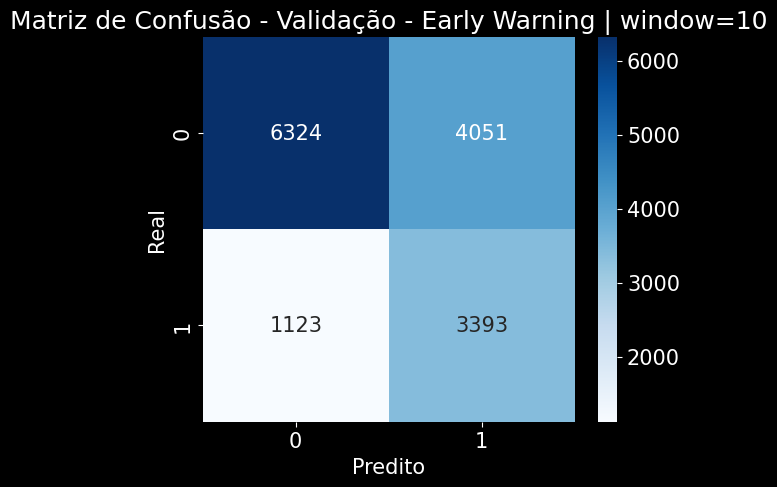


Melhor threshold na validação: 0.45000000000000007


,threshold,precision_classe_1,recall_classe_1,f1_classe_1
7,0.45,0.440056,0.833924,0.576105
6,0.40,0.421009,0.891054,0.571835
8,0.50,0.455803,0.751329,0.567391
5,0.35,0.396999,0.931577,0.556739
9,0.55,0.474161,0.637954,0.543995
4,0.30,0.371771,0.962356,0.536345
3,0.25,0.347179,0.980957,0.512850
2,0.20,0.327444,0.993136,0.492505
10,0.60,0.488109,0.477192,0.482589
1,0.15,0.314134,0.997564,0.477807


Arquivo salvo em: /content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/earlywarning_cnn_w10/thresholds.csv

AVALIAÇÃO - Validação - Early Warning (melhor threshold) | window=10 | threshold=0.45000000000000007

Métricas principais:
loss                  0.610021
accuracy              0.627829
precision_classe_1    0.440056
recall_classe_1       0.833924
f1_classe_1           0.576105
roc_auc               0.731660
pr_auc                0.473128
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.8816    0.5381    0.6683     10375
           1     0.4401    0.8339    0.5761      4516

    accuracy                         0.6278     14891
   macro avg     0.6608    0.6860    0.6222     14891
weighted avg     0.7477    0.6278    0.6403     14891



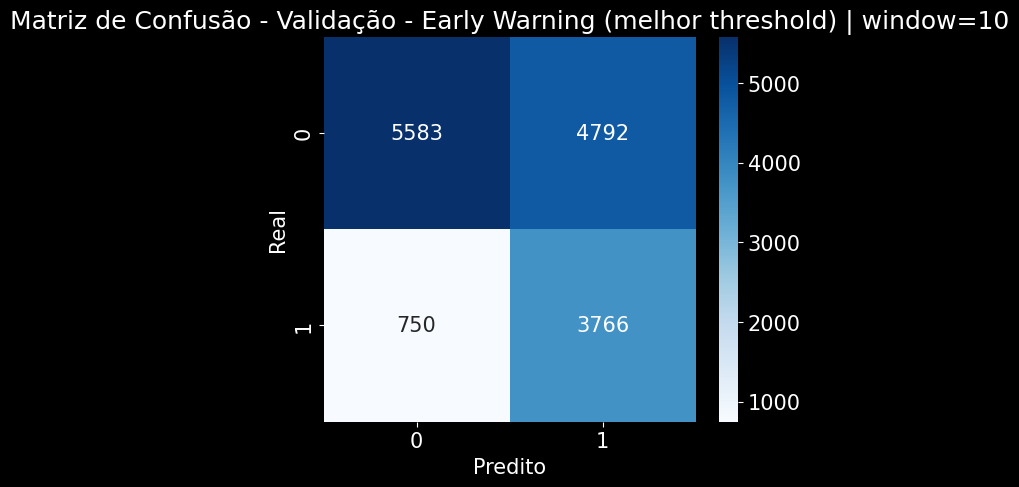


AVALIAÇÃO - Teste - Early Warning | window=10 | threshold=0.45000000000000007

Métricas principais:
loss                  0.615575
accuracy              0.610772
precision_classe_1    0.420931
recall_classe_1       0.818407
f1_classe_1           0.555930
roc_auc               0.719592
pr_auc                0.464336
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0     0.8717    0.5228    0.6536     10458
           1     0.4209    0.8184    0.5559      4433

    accuracy                         0.6108     14891
   macro avg     0.6463    0.6706    0.6047     14891
weighted avg     0.7375    0.6108    0.6245     14891



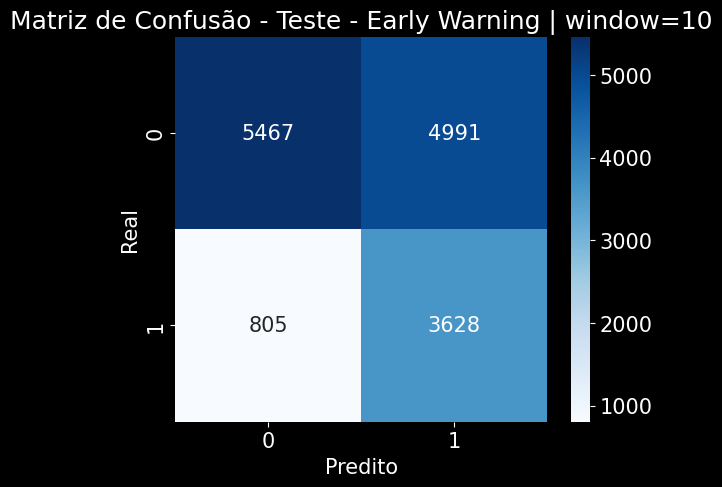

Arquivo salvo em: /content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/earlywarning_cnn_w10/summary.csv


In [45]:
early_warning_results = {}

for w in EARLY_WARNING_WINDOWS:
    early_warning_results[w] = run_cnn_early_warning_experiment(
        warning_window=w,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        force_retrain=False,
        evaluate_only_if_exists=False
    )

In [46]:
early_warning_summary_df = pd.DataFrame(
    [early_warning_results[w]["summary"] for w in EARLY_WARNING_WINDOWS]
)

display(
    early_warning_summary_df.sort_values(
        by=["test_f1_classe_1", "test_pr_auc", "test_roc_auc"],
        ascending=False
    )
)

,experiment_name,warning_window,threshold_escolhido,train_pos_rate,val_pos_rate,test_pos_rate,val_precision_classe_1,val_recall_classe_1,val_f1_classe_1,val_roc_auc,val_pr_auc,test_precision_classe_1,test_recall_classe_1,test_f1_classe_1,test_roc_auc,test_pr_auc
1,earlywarning_cnn_w10,10,0.45,0.293905,0.303270,0.297697,0.440056,0.833924,0.576105,0.731660,0.473128,0.420931,0.818407,0.555930,0.719592,0.464336
0,earlywarning_cnn_w5,5,0.45,0.146971,0.151719,0.148899,0.263753,0.846460,0.402186,0.749741,0.279122,0.248422,0.816050,0.380892,0.740148,0.269729


In [47]:
reports_dir = EXPERIMENTS_ROOT / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

early_warning_summary_path = reports_dir / "early_warning_summary.csv"
early_warning_summary_df.to_csv(early_warning_summary_path, index=False)

print("Resumo agregado de early warning salvo em:")
print(early_warning_summary_path)

Resumo agregado de early warning salvo em:
/content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/reports/early_warning_summary.csv


### Interpretation of the Early Warning Results

The early warning formulation produced a substantial change in the behavior of the problem. As expected, increasing the warning window increased the prevalence of the positive class, since more future intervals contained at least one failure. This confirms that the task became less strict than exact-step forecasting and, at the same time, more aligned with a practical maintenance scenario.

From the modeling perspective, both early warning settings clearly outperformed the exact-step multi-step experiments in terms of positive-class F1 and PR-AUC. The `window=10` configuration achieved the strongest overall operational performance, combining high recall with a much more acceptable precision level than the one observed in the exact-step formulation. Although `window=5` still showed useful predictive behavior, its results were consistently weaker than those of `window=10` in F1 and PR-AUC.

Therefore, the main conclusion of this section is that reformulating the task as an early warning problem was more impactful than merely changing the forecast horizon in the exact-step setup. In this project, the 1D CNN became considerably more useful when asked to predict whether failure would occur within a future interval rather than at one exact future instant.

## 7.3 Comparison Between Exact-Step Forecasting and Early Warning

At this point, the notebook contains two different formulations of the predictive maintenance problem:

1. **Exact-step forecasting**, in which the model predicts whether failure will occur at one specific future step;
2. **Early warning**, in which the model predicts whether at least one failure will occur within a future warning window.

This comparison is important because the two formulations do not answer the same operational question. Exact-step forecasting is stricter and temporally more precise, but it may be too difficult and brittle for a rare-event scenario. Early warning, on the other hand, is less precise in timing, yet potentially much more useful in practice because it supports earlier intervention.

The analysis below will compare the two approaches in terms of class prevalence, threshold-dependent performance, ranking quality, and practical usefulness. The goal is not only to identify which formulation yields better metrics, but also to understand which one produces a more realistic and actionable alerting behavior.

In [54]:
# ==========================================
# 7.3 COMPARISON BETWEEN FORMULATIONS
# Exact-step forecasting vs Early warning
# ==========================================

# --- 1) Standardize the multi-step table ---
multistep_compare_df = multistep_summary_df.copy()

multistep_compare_df["formulation"] = "Exact-step forecasting"
multistep_compare_df["window_or_horizon"] = multistep_compare_df["horizon"]
multistep_compare_df["formulation_detail"] = multistep_compare_df["horizon"].apply(
    lambda x: f"horizon={int(x)}"
)

multistep_compare_df = multistep_compare_df[[
    "formulation",
    "formulation_detail",
    "window_or_horizon",
    "threshold_escolhido",
    "train_pos_rate",
    "val_pos_rate",
    "test_pos_rate",
    "val_precision_classe_1",
    "val_recall_classe_1",
    "val_f1_classe_1",
    "val_roc_auc",
    "val_pr_auc",
    "test_precision_classe_1",
    "test_recall_classe_1",
    "test_f1_classe_1",
    "test_roc_auc",
    "test_pr_auc"
]].copy()

# --- 2) Standardize the early-warning table ---
earlywarning_compare_df = early_warning_summary_df.copy()

earlywarning_compare_df["formulation"] = "Early warning"
earlywarning_compare_df["window_or_horizon"] = earlywarning_compare_df["warning_window"]
earlywarning_compare_df["formulation_detail"] = earlywarning_compare_df["warning_window"].apply(
    lambda x: f"warning_window={int(x)}"
)

earlywarning_compare_df = earlywarning_compare_df[[
    "formulation",
    "formulation_detail",
    "window_or_horizon",
    "threshold_escolhido",
    "train_pos_rate",
    "val_pos_rate",
    "test_pos_rate",
    "val_precision_classe_1",
    "val_recall_classe_1",
    "val_f1_classe_1",
    "val_roc_auc",
    "val_pr_auc",
    "test_precision_classe_1",
    "test_recall_classe_1",
    "test_f1_classe_1",
    "test_roc_auc",
    "test_pr_auc"
]].copy()

# --- 3) Concatenate the two formulations ---
comparison_df = pd.concat(
    [multistep_compare_df, earlywarning_compare_df],
    axis=0,
    ignore_index=True
)

# --- 4) Sort by test performance ---
comparison_df = comparison_df.sort_values(
    by=["test_f1_classe_1", "test_pr_auc", "test_roc_auc"],
    ascending=False
).reset_index(drop=True)

print("Comparação consolidada entre formulações:")
display(comparison_df)

# --- 5) More concise version for quick review ---
comparison_compact_df = comparison_df[[
    "formulation",
    "formulation_detail",
    "threshold_escolhido",
    "test_pos_rate",
    "test_precision_classe_1",
    "test_recall_classe_1",
    "test_f1_classe_1",
    "test_roc_auc",
    "test_pr_auc"
]].copy()

print("Resumo enxuto focado no teste:")
display(comparison_compact_df)

# --- 6) Save to Drive ---
reports_dir = EXPERIMENTS_ROOT / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

comparison_full_path = reports_dir / "comparison_multistep_vs_earlywarning_full.csv"
comparison_compact_path = reports_dir / "comparison_multistep_vs_earlywarning_compact.csv"

comparison_df.to_csv(comparison_full_path, index=False)
comparison_compact_df.to_csv(comparison_compact_path, index=False)

print("Comparação completa salva em:")
print(comparison_full_path)

print("Comparação enxuta salva em:")
print(comparison_compact_path)

Comparação consolidada entre formulações:


,formulation,formulation_detail,window_or_horizon,threshold_escolhido,train_pos_rate,val_pos_rate,test_pos_rate,val_precision_classe_1,val_recall_classe_1,val_f1_classe_1,val_roc_auc,val_pr_auc,test_precision_classe_1,test_recall_classe_1,test_f1_classe_1,test_roc_auc,test_pr_auc
0,Early warning,warning_window=10,10,0.45,0.293905,0.303270,0.297697,0.440056,0.833924,0.576105,0.731660,0.473128,0.420931,0.818407,0.555930,0.719592,0.464336
1,Early warning,warning_window=5,5,0.45,0.146971,0.151719,0.148899,0.263753,0.846460,0.402186,0.749741,0.279122,0.248422,0.816050,0.380892,0.740148,0.269729
2,Exact-step forecasting,horizon=1,1,0.50,0.029392,0.030336,0.029799,0.062053,0.767699,0.114825,0.753548,0.066313,0.057306,0.725225,0.106218,0.737160,0.061051
3,Exact-step forecasting,horizon=5,5,0.55,0.029394,0.030344,0.029807,0.055961,0.457965,0.099735,0.696797,0.051238,0.047502,0.391892,0.084733,0.675133,0.046815
4,Exact-step forecasting,horizon=10,10,0.55,0.029396,0.030354,0.029817,0.060590,0.245575,0.097198,0.664382,0.053513,0.051633,0.220721,0.083689,0.630185,0.045081


Resumo enxuto focado no teste:


,formulation,formulation_detail,threshold_escolhido,test_pos_rate,test_precision_classe_1,test_recall_classe_1,test_f1_classe_1,test_roc_auc,test_pr_auc
0,Early warning,warning_window=10,0.45,0.297697,0.420931,0.818407,0.555930,0.719592,0.464336
1,Early warning,warning_window=5,0.45,0.148899,0.248422,0.816050,0.380892,0.740148,0.269729
2,Exact-step forecasting,horizon=1,0.50,0.029799,0.057306,0.725225,0.106218,0.737160,0.061051
3,Exact-step forecasting,horizon=5,0.55,0.029807,0.047502,0.391892,0.084733,0.675133,0.046815
4,Exact-step forecasting,horizon=10,0.55,0.029817,0.051633,0.220721,0.083689,0.630185,0.045081


Comparação completa salva em:
/content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/reports/comparison_multistep_vs_earlywarning_full.csv
Comparação enxuta salva em:
/content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/reports/comparison_multistep_vs_earlywarning_compact.csv


### Reading the Comparison Between Formulations

This table compares the same CNN 1D architecture under two different target definitions. The goal is to determine whether the main gains came from extending the forecast horizon under exact-step forecasting or from reformulating the task as an early warning problem.

Particular attention should be given to the positive-class F1 and PR-AUC on the test set, since these metrics are more informative in the presence of class imbalance. The comparison should also consider the prevalence of the positive class, because early warning naturally broadens the definition of positive events and may therefore improve operational usefulness while reducing temporal precision.

### Interpretation of the Comparison Between Formulations

The comparison between formulations showed that the main performance gains in this project did not come from increasing the exact forecast horizon, but from changing the target definition itself. Under exact-step forecasting, the model had to predict failure at one specific future instant, which led to very low positive-class F1 and PR-AUC across all tested horizons. As the horizon increased, the task became harder and the discriminative performance deteriorated.

In contrast, the early warning formulation produced substantially stronger results. By redefining the target as the occurrence of at least one failure within a future interval, the problem became less strict and more operationally meaningful. This change increased the prevalence of the positive class, reduced the severity of class imbalance, and allowed the same 1D CNN architecture to achieve much better positive-class precision, recall, F1, and PR-AUC.

Among all tested setups, the `warning_window=10` configuration delivered the best overall operational trade-off. Therefore, the main conclusion of this comparison is that, for this project, early warning is a more useful and effective formulation than exact-step forecasting. The architecture itself remained the same; what changed the practical value of the model was the way the predictive task was defined.

## 7.4 Simple Temporal Post-processing of Alerts

At this point, the best-performing formulation in the notebook is the early warning setup, especially with a wider warning window. However, even when predictive performance is satisfactory, the raw sequence of alerts may still be noisy or unstable over time.

In practical predictive maintenance scenarios, isolated spikes are often less useful than temporally consistent alert patterns. For this reason, this section applies simple causal post-processing strategies to the alert stream generated by the best early warning model, without retraining the neural network itself.

The goal is to verify whether a small amount of temporal smoothing can improve the operational behavior of the alerts, either by increasing precision, reducing fragmentation, or producing a more stable alert sequence.

### Post-processing Strategies

Two simple temporal strategies will be tested:

1. **Causal moving average on scores**  
   The predicted probabilities are smoothed using only the current and previous scores. This may reduce isolated fluctuations before thresholding.

2. **k-of-n rule on binary alerts**  
   After converting scores into binary alerts, an alert is emitted only if at least `k` positive predictions occur within the last `n` steps. This favors persistence and discourages isolated positives.

Importantly, both strategies are causal: they use only present and past information, which makes them consistent with a real alerting scenario.

In [55]:
# ==========================================
# 7.4 - SELECT THE BEST EARLY-WARNING MODEL
# ==========================================

if "early_warning_summary_df" in globals():
    best_ew_row = early_warning_summary_df.sort_values(
        by=["test_f1_classe_1", "test_pr_auc", "test_roc_auc"],
        ascending=False
    ).iloc[0]

    BEST_EW_WINDOW = int(best_ew_row["warning_window"])
    BEST_EW_THRESHOLD = float(best_ew_row["threshold_escolhido"])
else:
    # fallback based on the current observed results
    BEST_EW_WINDOW = 10
    BEST_EW_THRESHOLD = 0.45

print("Melhor configuração de early warning selecionada:")
print("BEST_EW_WINDOW   =", BEST_EW_WINDOW)
print("BEST_EW_THRESHOLD =", BEST_EW_THRESHOLD)

Melhor configuração de early warning selecionada:
BEST_EW_WINDOW   = 10
BEST_EW_THRESHOLD = 0.45000000000000007


### Loading the Best Early Warning Model

The best early warning configuration identified in the previous section will now be reloaded from disk. The validation and test windows will be reconstructed using the same warning window so that post-processing can be calibrated on the validation set and then evaluated once on the test set.

In [56]:
# ==========================================
# 7.4 - LOAD THE BEST EARLY-WARNING MODEL
# ==========================================

best_ew_experiment_name = f"earlywarning_cnn_w{BEST_EW_WINDOW}"
best_ew_paths = make_experiment_paths(best_ew_experiment_name)

best_ew_model = tf.keras.models.load_model(str(best_ew_paths["best_model_path"]))

X_val_ew, y_val_ew = build_early_warning_windows(
    val_features, val_target,
    samples=BACK_LOG,
    warning_window=BEST_EW_WINDOW
)

X_test_ew, y_test_ew = build_early_warning_windows(
    test_features, test_target,
    samples=BACK_LOG,
    warning_window=BEST_EW_WINDOW
)

y_score_val_raw = best_ew_model.predict(X_val_ew, batch_size=BATCH_SIZE, verbose=0).ravel()
y_score_test_raw = best_ew_model.predict(X_test_ew, batch_size=BATCH_SIZE, verbose=0).ravel()

print("Shapes:")
print("X_val_ew :", X_val_ew.shape, "| y_val_ew :", y_val_ew.shape)
print("X_test_ew:", X_test_ew.shape, "| y_test_ew:", y_test_ew.shape)

Shapes:
X_val_ew : (14891, 50, 2) | y_val_ew : (14891,)
X_test_ew: (14891, 50, 2) | y_test_ew: (14891,)


### Helper Functions for Alert Evaluation

Since this section compares alert streams rather than model training, the evaluation will focus on threshold-dependent operational metrics such as precision, recall, F1, and also on simple alert-stream descriptors such as alert rate and the number of alert bursts.

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

# ==========================================
# POST-PROCESSING HELPERS
# ==========================================

def moving_average_causal(scores, window=3):
    return pd.Series(scores).rolling(window=window, min_periods=1).mean().to_numpy()

def k_of_n_filter(binary_alerts, n=3, k=2):
    binary_alerts = np.asarray(binary_alerts).astype(int)
    filtered = []

    for i in range(len(binary_alerts)):
        start = max(0, i - n + 1)
        recent_block = binary_alerts[start:i+1]
        filtered.append(int(recent_block.sum() >= k))

    return np.asarray(filtered, dtype=int)

def count_alert_bursts(binary_alerts):
    binary_alerts = np.asarray(binary_alerts).astype(int)
    if len(binary_alerts) == 0:
        return 0

    starts = int(binary_alerts[0] == 1)
    starts += int(np.sum((binary_alerts[1:] == 1) & (binary_alerts[:-1] == 0)))
    return starts

def count_alert_transitions(binary_alerts):
    binary_alerts = np.asarray(binary_alerts).astype(int)
    if len(binary_alerts) <= 1:
        return 0
    return int(np.sum(binary_alerts[1:] != binary_alerts[:-1]))

def evaluate_binary_alerts(y_true, y_pred, label="method"):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    result = {
        "method": label,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_classe_1": precision_score(y_true, y_pred, zero_division=0),
        "recall_classe_1": recall_score(y_true, y_pred, zero_division=0),
        "f1_classe_1": f1_score(y_true, y_pred, zero_division=0),
        "alert_rate": float(np.mean(y_pred)),
        "alert_bursts": count_alert_bursts(y_pred),
        "alert_transitions": count_alert_transitions(y_pred),
    }
    return result

def evaluate_scores_with_threshold(y_true, y_score, threshold=0.5, label="method"):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score, dtype=float)
    y_pred = (y_score >= threshold).astype(int)

    result = evaluate_binary_alerts(y_true, y_pred, label=label)
    result["threshold"] = float(threshold)
    result["roc_auc"] = roc_auc_score(y_true, y_score)
    result["pr_auc"] = average_precision_score(y_true, y_score)

    return result, y_pred

### Raw Alert Stream Baseline

Before applying any temporal post-processing, the raw early warning scores will be evaluated using the threshold previously selected on the validation set. This provides the reference point against which all smoothed versions will be compared.

In [58]:
# ==========================================
# RAW BASELINE
# ==========================================

raw_val_result, raw_val_pred = evaluate_scores_with_threshold(
    y_true=y_val_ew,
    y_score=y_score_val_raw,
    threshold=BEST_EW_THRESHOLD,
    label=f"raw_alerts_w{BEST_EW_WINDOW}"
)

raw_test_result, raw_test_pred = evaluate_scores_with_threshold(
    y_true=y_test_ew,
    y_score=y_score_test_raw,
    threshold=BEST_EW_THRESHOLD,
    label=f"raw_alerts_w{BEST_EW_WINDOW}"
)

print("Baseline - validação")
display(pd.DataFrame([raw_val_result]))

print("Baseline - teste")
display(pd.DataFrame([raw_test_result]))

Baseline - validação


,method,accuracy,precision_classe_1,recall_classe_1,f1_classe_1,alert_rate,alert_bursts,alert_transitions,threshold,roc_auc,pr_auc
0,raw_alerts_w10,0.627829,0.440056,0.833924,0.576105,0.57471,677,1353,0.45,0.73166,0.473128


Baseline - teste


,method,accuracy,precision_classe_1,recall_classe_1,f1_classe_1,alert_rate,alert_bursts,alert_transitions,threshold,roc_auc,pr_auc
0,raw_alerts_w10,0.610772,0.420931,0.818407,0.55593,0.578806,684,1367,0.45,0.719592,0.464336


### Tuning Causal Moving Average on Validation

The first post-processing strategy smooths the raw probability sequence before thresholding. The smoothing window will be selected on the validation set, and the best threshold for each smoothed sequence will also be chosen on validation only.

In [59]:
# ==========================================
# TUNING - MOVING AVERAGE
# ==========================================

MA_WINDOWS = [3, 5, 7]
ma_tuning_rows = []

for ma_window in MA_WINDOWS:
    y_score_val_ma = moving_average_causal(y_score_val_raw, window=ma_window)

    best_ma_threshold, ma_threshold_df = choose_best_threshold(
        y_true=y_val_ew,
        y_score=y_score_val_ma,
        thresholds=MULTI_THRESHOLDS
    )

    ma_val_result, ma_val_pred = evaluate_scores_with_threshold(
        y_true=y_val_ew,
        y_score=y_score_val_ma,
        threshold=best_ma_threshold,
        label=f"moving_average_w{ma_window}"
    )

    ma_val_result["ma_window"] = ma_window
    ma_tuning_rows.append(ma_val_result)

ma_tuning_df = pd.DataFrame(ma_tuning_rows).sort_values(
    by=["f1_classe_1", "precision_classe_1", "recall_classe_1"],
    ascending=False
).reset_index(drop=True)

display(ma_tuning_df)

best_ma_row = ma_tuning_df.iloc[0]
BEST_MA_WINDOW = int(best_ma_row["ma_window"])
BEST_MA_THRESHOLD = float(best_ma_row["threshold"])

print("Melhor configuração de moving average:")
print("BEST_MA_WINDOW   =", BEST_MA_WINDOW)
print("BEST_MA_THRESHOLD =", BEST_MA_THRESHOLD)

,method,accuracy,precision_classe_1,recall_classe_1,f1_classe_1,alert_rate,alert_bursts,alert_transitions,threshold,roc_auc,pr_auc,ma_window
0,moving_average_w3,0.580552,0.410455,0.877989,0.559396,0.648714,561,1121,0.4,0.713854,0.452862,3
1,moving_average_w5,0.561749,0.397050,0.858282,0.542933,0.655564,531,1061,0.4,0.689818,0.431155,5
2,moving_average_w7,0.540192,0.382022,0.835695,0.524349,0.663421,507,1013,0.4,0.659861,0.408257,7


Melhor configuração de moving average:
BEST_MA_WINDOW   = 3
BEST_MA_THRESHOLD = 0.40000000000000013


### Tuning the k-of-n Rule on Validation

The second strategy applies a persistence rule to the binary alerts generated by the raw model. The base threshold remains the one previously selected for the best early warning model, and the k-of-n parameters are chosen using validation performance.

In [60]:
# ==========================================
# TUNING - K-OF-N
# ==========================================

KOFN_CONFIGS = [
    (3, 2),
    (3, 3),
    (5, 2),
    (5, 3),
    (5, 4),
]

raw_val_binary = (y_score_val_raw >= BEST_EW_THRESHOLD).astype(int)

kofn_tuning_rows = []

for n, k in KOFN_CONFIGS:
    y_val_kofn = k_of_n_filter(raw_val_binary, n=n, k=k)

    result = evaluate_binary_alerts(
        y_true=y_val_ew,
        y_pred=y_val_kofn,
        label=f"k_of_n_{k}_of_{n}"
    )

    result["n"] = n
    result["k"] = k
    kofn_tuning_rows.append(result)

kofn_tuning_df = pd.DataFrame(kofn_tuning_rows).sort_values(
    by=["f1_classe_1", "precision_classe_1", "recall_classe_1"],
    ascending=False
).reset_index(drop=True)

display(kofn_tuning_df)

best_kofn_row = kofn_tuning_df.iloc[0]
BEST_KOFN_N = int(best_kofn_row["n"])
BEST_KOFN_K = int(best_kofn_row["k"])

print("Melhor configuração k-of-n:")
print("BEST_KOFN_K =", BEST_KOFN_K)
print("BEST_KOFN_N =", BEST_KOFN_N)

,method,accuracy,precision_classe_1,recall_classe_1,f1_classe_1,alert_rate,alert_bursts,alert_transitions,n,k
0,k_of_n_2_of_3,0.612921,0.427273,0.811780,0.559866,0.576187,602,1203,3,2
1,k_of_n_3_of_3,0.648177,0.450048,0.721213,0.554241,0.485998,614,1227,3,3
2,k_of_n_2_of_5,0.558928,0.395604,0.860939,0.542108,0.659996,533,1065,5,2
3,k_of_n_3_of_5,0.595729,0.412842,0.788751,0.541996,0.579410,551,1101,5,3
4,k_of_n_4_of_5,0.628769,0.431081,0.700841,0.533817,0.493049,568,1135,5,4


Melhor configuração k-of-n:
BEST_KOFN_K = 2
BEST_KOFN_N = 3


### Final Comparison on the Test Set

After selecting the best moving average and k-of-n configurations on validation, the final comparison is performed on the test set. This allows us to verify whether simple temporal smoothing improves the practical behavior of the alert stream without changing the trained neural network.

In [61]:
# ==========================================
# FINAL EVALUATION ON THE TEST SET
# ==========================================

# Moving average
y_score_val_ma_best = moving_average_causal(y_score_val_raw, window=BEST_MA_WINDOW)
y_score_test_ma_best = moving_average_causal(y_score_test_raw, window=BEST_MA_WINDOW)

ma_val_result_best, ma_val_pred_best = evaluate_scores_with_threshold(
    y_true=y_val_ew,
    y_score=y_score_val_ma_best,
    threshold=BEST_MA_THRESHOLD,
    label=f"moving_average_best_w{BEST_MA_WINDOW}"
)

ma_test_result_best, ma_test_pred_best = evaluate_scores_with_threshold(
    y_true=y_test_ew,
    y_score=y_score_test_ma_best,
    threshold=BEST_MA_THRESHOLD,
    label=f"moving_average_best_w{BEST_MA_WINDOW}"
)

# k-of-n
raw_test_binary = (y_score_test_raw >= BEST_EW_THRESHOLD).astype(int)

kofn_val_pred_best = k_of_n_filter(raw_val_binary, n=BEST_KOFN_N, k=BEST_KOFN_K)
kofn_test_pred_best = k_of_n_filter(raw_test_binary, n=BEST_KOFN_N, k=BEST_KOFN_K)

kofn_val_result_best = evaluate_binary_alerts(
    y_true=y_val_ew,
    y_pred=kofn_val_pred_best,
    label=f"k_of_n_best_{BEST_KOFN_K}_of_{BEST_KOFN_N}"
)

kofn_test_result_best = evaluate_binary_alerts(
    y_true=y_test_ew,
    y_pred=kofn_test_pred_best,
    label=f"k_of_n_best_{BEST_KOFN_K}_of_{BEST_KOFN_N}"
)

# Consolidated
postprocessing_val_df = pd.DataFrame([
    raw_val_result,
    ma_val_result_best,
    kofn_val_result_best
])

postprocessing_test_df = pd.DataFrame([
    raw_test_result,
    ma_test_result_best,
    kofn_test_result_best
])

print("Comparação na validação:")
display(postprocessing_val_df.sort_values(
    by=["f1_classe_1", "precision_classe_1", "recall_classe_1"],
    ascending=False
))

print("Comparação no teste:")
display(postprocessing_test_df.sort_values(
    by=["f1_classe_1", "precision_classe_1", "recall_classe_1"],
    ascending=False
))

Comparação na validação:


,method,accuracy,precision_classe_1,recall_classe_1,f1_classe_1,alert_rate,alert_bursts,alert_transitions,threshold,roc_auc,pr_auc
0,raw_alerts_w10,0.627829,0.440056,0.833924,0.576105,0.574710,677,1353,0.45,0.731660,0.473128
2,k_of_n_best_2_of_3,0.612921,0.427273,0.811780,0.559866,0.576187,602,1203,NaN,NaN,NaN
1,moving_average_best_w3,0.580552,0.410455,0.877989,0.559396,0.648714,561,1121,0.40,0.713854,0.452862


Comparação no teste:


,method,accuracy,precision_classe_1,recall_classe_1,f1_classe_1,alert_rate,alert_bursts,alert_transitions,threshold,roc_auc,pr_auc
0,raw_alerts_w10,0.610772,0.420931,0.818407,0.555930,0.578806,684,1367,0.45,0.719592,0.464336
1,moving_average_best_w3,0.562017,0.393473,0.870291,0.541930,0.658451,555,1109,0.40,0.698685,0.439770
2,k_of_n_best_2_of_3,0.595460,0.408067,0.796526,0.539661,0.581089,603,1205,NaN,NaN,NaN


In [62]:
# ==========================================
# SAVE RESULTS TO DRIVE
# ==========================================

reports_dir = EXPERIMENTS_ROOT / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

ma_tuning_path = reports_dir / "postprocessing_moving_average_tuning.csv"
kofn_tuning_path = reports_dir / "postprocessing_kofn_tuning.csv"
postprocessing_val_path = reports_dir / "postprocessing_validation_comparison.csv"
postprocessing_test_path = reports_dir / "postprocessing_test_comparison.csv"

ma_tuning_df.to_csv(ma_tuning_path, index=False)
kofn_tuning_df.to_csv(kofn_tuning_path, index=False)
postprocessing_val_df.to_csv(postprocessing_val_path, index=False)
postprocessing_test_df.to_csv(postprocessing_test_path, index=False)

print("Arquivos salvos em:")
print(ma_tuning_path)
print(kofn_tuning_path)
print(postprocessing_val_path)
print(postprocessing_test_path)

Arquivos salvos em:
/content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/reports/postprocessing_moving_average_tuning.csv
/content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/reports/postprocessing_kofn_tuning.csv
/content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/reports/postprocessing_validation_comparison.csv
/content/drive/MyDrive/projeto_manutencao_preditiva/experimentos/reports/postprocessing_test_comparison.csv


### Interpretation of the Post-processing Results

The raw early warning model remained the best option in terms of positive-class F1 on the test set. Neither causal moving average nor the k-of-n rule improved the core predictive metrics, but both reduced alert fragmentation, producing fewer alert bursts and fewer alert transitions over time.

This suggests that simple temporal post-processing may still be useful from an operational perspective, even when it does not improve classification performance. In this experiment, the main gain of post-processing was greater temporal stability of the alert stream rather than higher predictive quality.

## 8. Final Discussion and Conclusions

This notebook evolved from a simple academic exercise into a more rigorous predictive maintenance study. The final pipeline incorporated temporal split with gap, normalization fitted only on the training set, threshold calibration on validation only, and a cleaner final test protocol.

At the baseline stage, the 1D CNN consistently outperformed the LSTM and became the main architecture for the rest of the project. However, exact-step forecasting remained difficult, especially at longer horizons, with very low positive-class F1 and PR-AUC.

The most important gain of the notebook came from reformulating the task as early warning rather than exact-step forecasting. Under this setup, the same 1D CNN became much more useful operationally, especially with a warning window of 10 steps. Finally, simple temporal post-processing did not improve the best predictive metrics, but it did reduce alert fragmentation and made the alert stream more stable over time.

### 8.1 Limitations

This project still has important limitations. The dataset is synthetic and contains only two sensor variables, which simplifies the real-world complexity of predictive maintenance. In addition, although early warning substantially improved the results, the model is still not a production-ready system and should be interpreted as a promising prototype rather than a final operational solution.

Another limitation is that the study focused mainly on CNN 1D and LSTM, without a broader architecture benchmark. Finally, the post-processing stage remained intentionally simple, so more advanced alert-control strategies were left outside the current scope.

### 8.2 Future Work

Possible next steps include expanding the feature space with derived temporal statistics, testing stronger sequence architectures, and optimizing threshold selection jointly with post-processing rules. It would also be useful to introduce more operational metrics, such as false alarms per segment, average alert lead time, and alert persistence.

From an application perspective, the most relevant continuation would be to refine the early warning formulation, since it was the main source of practical improvement in this notebook. Future work should therefore prioritize operational usefulness and robustness rather than only exact timestamp prediction.